# SegueII


propermotion = False
individual = True
esc_check = False



[[ 5.77597612e-02  5.41788458e+00  5.00000000e+00]
 [ 4.62294879e-02  7.17884582e-01  1.35000000e+01]
 [ 3.88972654e-02  2.71788458e+00  2.00000000e+00]
 [ 4.24444853e-02  1.78845817e-02  2.10000000e+00]
 [ 7.16910841e-02 -4.28211542e+00  4.90000000e+00]
 [ 2.74028620e-02  1.91788458e+00  2.30000000e+00]
 [ 1.81371065e-02 -3.08211542e+00  1.07000000e+01]
 [ 2.82188184e-02 -2.28211542e+00  2.10000000e+00]
 [ 4.07138366e-02  5.17884582e-01  1.09000000e+01]
 [ 1.05805661e-02 -9.82115418e-01  2.10000000e+00]
 [ 5.59379275e-03  4.01788458e+00  1.37000000e+01]
 [ 4.15819740e-02  1.17884582e-01  2.25000000e+01]
 [ 6.14511482e-03 -1.98211542e+00  2.40000000e+00]
 [ 2.90695653e-02  3.51788458e+00  2.20000000e+00]
 [ 3.14693091e-02  1.11788458e+00  5.40000000e+00]
 [ 6.11416797e-02 -1.58211542e+00  2.00000000e+00]
 [ 1.99758719e-02  2.17884582e-01  2.00000000e+00]
 [ 2.97241901e-02  3.81788458e+00  3.70000000e+00]
 [ 4.06469461e-02  2.11788458e+00  8.60000000e+00]
 [ 3.15634137e-02  4.17884582e-

/tmp/ipykernel_1746579/2869361981.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


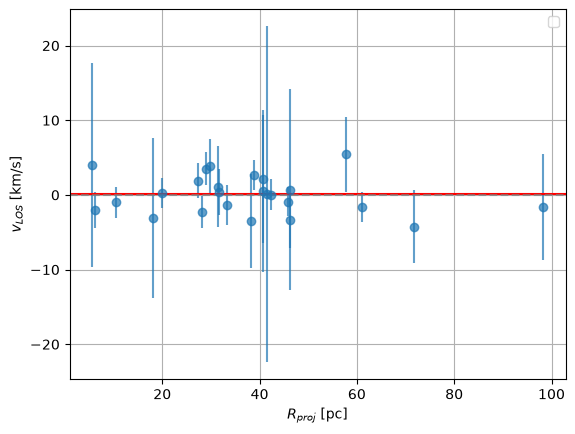

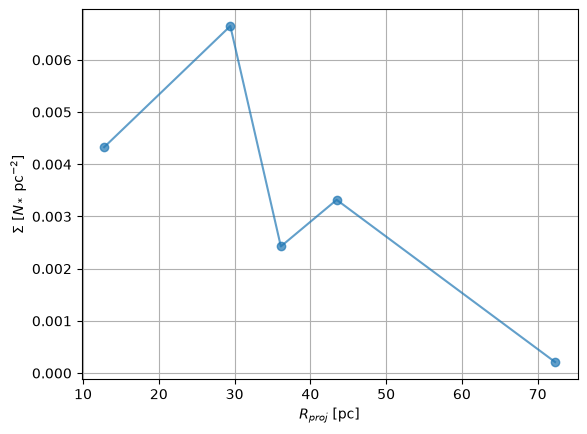

In [1]:
data_dir = 'Data/Seg2'

import os
import numpy as np
import pandas as pd


Seg2_data = np.loadtxt(os.path.join(data_dir, 'Seg2_Rproj_vlos_vloserr.txt'))

import matplotlib.pyplot as plt


print(Seg2_data)

plt.errorbar(Seg2_data[:,0] * 1000, Seg2_data[:,1], yerr = Seg2_data[:,2], marker = 'o', linestyle=' ', alpha = 0.7)
plt.axhline(np.mean(Seg2_data[:,1]), color = 'red')
#plt.axvline(np.min(Seg2_data[:,0])*1000, color = 'green', label = f'Minimum R_proj = {np.min(Seg2_data[:,0])*1000:.3f} pc', alpha = 0.5)
plt.axhline(0, linestyle = '--', color = 'grey', alpha = 0.7)
plt.xlabel(r'$R_{proj}$ [pc]')
plt.ylabel(r'$v_{LOS}$ [km/s]')
plt.grid()
plt.legend()
plt.show()

r_los = Seg2_data[:,0]
v_los = Seg2_data[:,1]
v_los_err = Seg2_data[:,2]

r_los_sorted_pc = sorted(r_los * 1000)

no_of_bins = 5 # as 25 stars

no_of_stars_per_bin = len(r_los)/no_of_bins

Sigma = []

bin_centers = []

for i in range(no_of_bins):

    bin_l_edge = r_los_sorted_pc[0 + i*5]

    bin_r_edge = r_los_sorted_pc[4 + i*5]

    bin_area = np.pi * (bin_r_edge**2 - bin_l_edge**2)

    Sigma.append(5 / bin_area) 

    bin_centers.append((bin_l_edge + bin_r_edge) / 2)


plt.plot(bin_centers, Sigma, marker = 'o', alpha = 0.7)
plt.xlabel(r'$R_{proj}$ [pc]')
plt.ylabel(r'$\Sigma$ [$N_*$ pc$^{-2}$]')
plt.grid()
plt.show()


In [2]:

os.environ['GS2_OBJECT'] = 'Seg2'

#The gravsphere2 file defines the likelihood for sampling and opens the initialization file with the specific object
#with all the data, this is an example script doing some of the plots

#Our default example is for the Fornax LOS + PM simulation mock with 100 tracers

from gravsphere2 import *

import matplotlib.pyplot as plt

import dynesty
from dynesty import plotting as dyplot
from dynesty import DynamicNestedSampler

%matplotlib inline

#open sampling chain, in this case we open one that should have been already run (Fornax sim for 100 tracers + PMs)


diro = '/gpfs/home/jd925/GravSphere2/Output/Segue2/'
print(diro)
resu = DynamicNestedSampler.restore(str(diro + 'Sampler Chains/seg2_chk')).results

print(resu["logl"][-1], lnprob(resu.samples[-1]))

#--- is this the right chain? -----------------------------------------------------------------
# Re-evaluating lnprob on the last stored sample has to reproduce the stored
# logl: if diro points at another object's Output/ tree, the sample has the
# wrong dimension or the wrong data behind it and this fails loudly instead of
# quietly plotting the wrong galaxy.
assert name == 'Segue2', 'gravsphere2 is set up for %r, not Segue2' % name
assert np.isclose(resu['logl'][-1], lnprob(resu.samples[-1])), \
    'restored chain does not match the current setup (%s)' % name
print('chain OK: %s, ndims = %d, %d iterations' % (name, ndims, resu.niter))



[gravsphere2] GS2_OBJECT = Seg2 -> from initialise_Seg2 import *
[initialise_Seg2] N = 25 tracers from Seg2_Rproj_vlos_vloserr.txt, individual = True, output -> Output/Segue2/
/gpfs/home/jd925/GravSphere2/Output/Segue2/
-46.97615939237083 -46.97615939237083
chain OK: Segue2, ndims = 18, 14808 iterations


number of sampling iterations =  14808


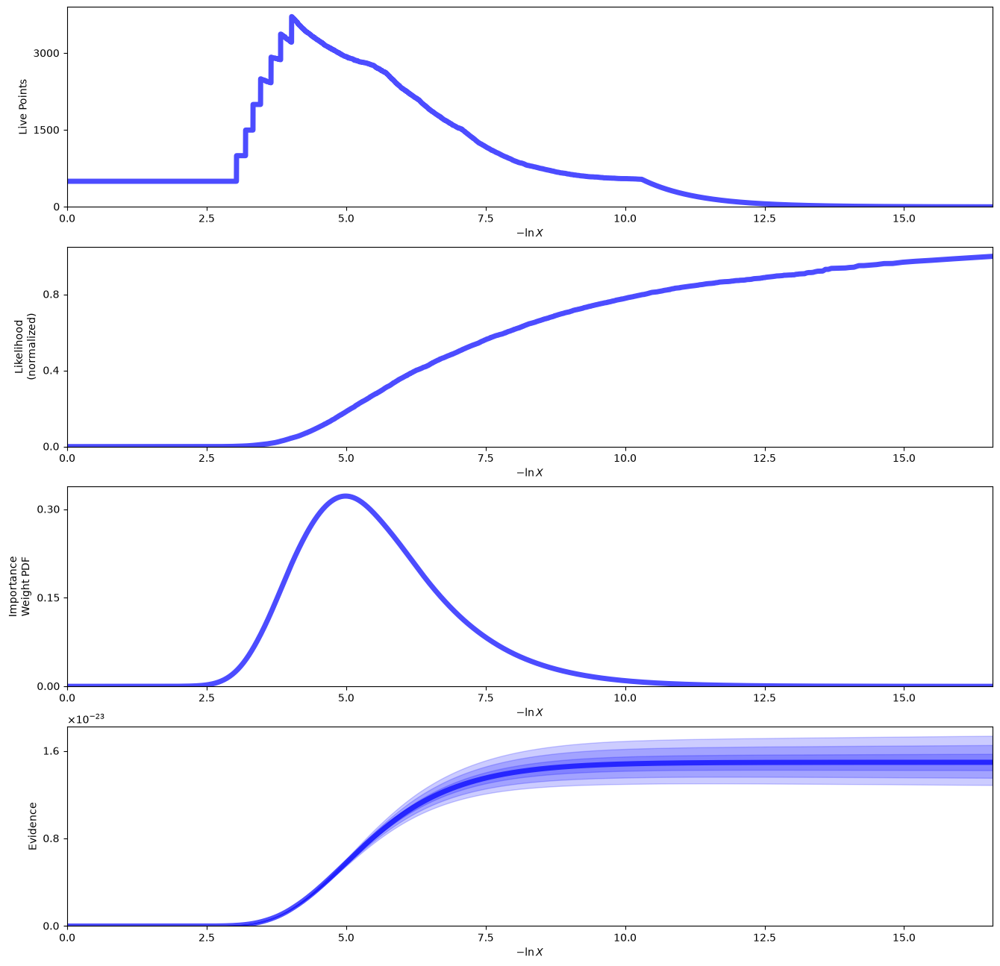

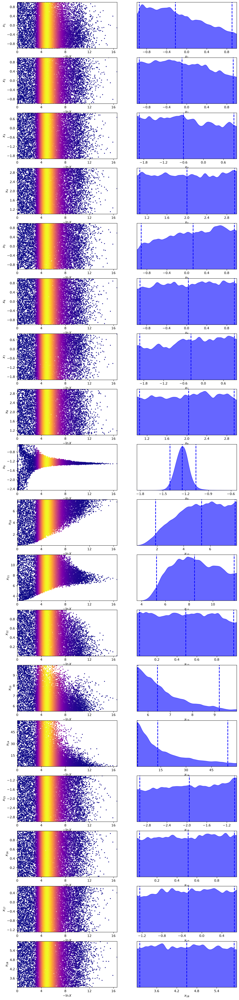

In [3]:
#diagnostic plot of the run, if the sampler has converged, the number of live points and weights should go to zero
#we can see this sampler has coverged correctly

print("number of sampling iterations = ", resu.niter)

from dynesty import plotting as dyplot

%matplotlib inline

# Plot a summary of the run.
rfig, raxes = dyplot.runplot(resu)

# Plot traces and 1-D marginalized posteriors.
tfig, taxes = dyplot.traceplot(resu)

plt.show()

In [4]:
#--- Segue2 setup: numbers from the run, radial grid, style helpers ---------------------------

s1flat = resu.samples_equal()      # equal-weight posterior samples, shape (Nsamp, ndims)


print('N tracers        = %d   (LOS only)' % len(rLOS))
print('R_proj range     = %.4f - %.4f kpc   (R_half = %.4f kpc)' % (rLOS.min(), rLOS.max(), Rhalf))
print('ndims            = %d' % ndims)
print('iterations       = %d,  calls = %d,  eff = %.2f%%'
      % (resu.niter, resu.ncall.sum(), 100*resu.niter/resu.ncall.sum()))
print('log Z            = %.3f +/- %.3f' % (resu.logz[-1], resu.logzerr[-1]))
print('max log L        = %.3f' % resu.logl.max())
print('equal-wt samples = %d' % len(s1flat))

# parameter order in Theta (individual == True, so ndims = 18, or 19 with Mstar)
s1labs = ['bet0_t', 'betinf_t', 'log rbeta', 'eta',            # 0-3  2nd-order anisotropy
          "bet0_t'", "betinf_t'", "log rbeta'", "eta'",        # 4-7  4th-order anisotropy
          'log rp', 'alp_p', 'bet_p', 'gam_p',                 # 8-11 tracer light profile
          'logM200', 'c200', 'log rc', 'n', 'log rt', 'delta'] # 12-17 coreNFWtides

# Mstar (index 18) is sampled linearly in Msun, so show it in units of 1e6 Msun to
# keep the column widths of the table; everything else is printed as sampled.
s1scale = np.ones(ndims)
if Mstar != 0.0:
    s1labs.append('Mstar/1e6')                                 # 18   stellar mass
    s1scale[-1] = 1.0e-6

print('\n%-11s %9s %9s %9s %9s   %s' % ('param', 'mean', '16%', '50%', '84%', 'prior'))
for i, l in enumerate(s1labs):
    sc = s1scale[i]
    mean = np.mean(s1flat[:, i])*sc
    q = np.percentile(s1flat[:, i], [16, 50, 84])*sc
    lo, hi = minarr[i]*sc, maxarr[i]*sc
    flag = ''
    if q[0] - lo < 0.05*(hi-lo): flag += '  <- at lower prior edge'
    if hi - q[2] < 0.05*(hi-lo): flag += '  <- at upper prior edge'
    print('%-11s %9.6f %9.6f %9.6f %9.6f   [%.2f, %.2f]%s'
          % (l, mean, q[0], q[1], q[2], lo, hi, flag))

#--- plotting setup --------------------------------------------------------------------------
col, al = 'mediumseagreen', 0.7
leg = r'Segue2 (%d stars, LOS only)' % len(rLOS)
Rmax_dat = np.max(rLOS)                                  # outermost member, 90 pc
Ra = np.logspace(np.log10(1e-3), np.log10(rmax), 300)   
fsl = fst = 26*1.3

plt.style.use('default')
from matplotlib import rc
rc('axes', linewidth=1)
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)
rc('font', weight='bold')


def band(samples_2d, levels=(0.0275, 0.16, 0.5, 0.84, 0.975)):
    """95%, 68% and median envelopes of an (Nsamp, Nr) array of profiles."""
    return np.nanpercentile(samples_2d, 100*np.array(levels), axis=0)


def pretty_ax(ax, ylo, yhi, xlo=Ra.min(), xhi=Ra.max(), logy=False):
    """Fornax-notebook axis styling, plus R_half and an 'outside the data' shading."""
    ax.axvline(Rhalf, ls='--', color='gray', lw=3.0, zorder=0)
    #ax.axvspan(Rmax_dat, xhi, color='0.85', alpha=0.6, zorder=-5)   # no tracers out here
    ax.set_xscale('log')
    if logy:
        ax.set_yscale('log')
    ax.set_xlim(xlo, xhi)
    ax.set_ylim(ylo, yhi)
    ax.tick_params(labelsize=fst)
    ax.tick_params('both', length=8.5, width=2.5, which='major', direction='out')
    ax.tick_params('both', length=5, width=1.8, which='minor', direction='out')
    axx, axy = ax.secondary_yaxis('right'), ax.secondary_xaxis('top')
    for sec in (axx, axy):
        sec.tick_params('both', length=8.5, width=2.5, which='major', direction='in')
        sec.tick_params('both', length=5, width=1.8, which='minor', direction='in')
    axx.set_yticklabels([])
    axy.set_xticklabels([])
    for s in ['top', 'bottom', 'left', 'right']:
        ax.spines[s].set_linewidth(2.5)


N tracers        = 25   (LOS only)
R_proj range     = 0.0056 - 0.0983 kpc   (R_half = 0.0346 kpc)
ndims            = 18
iterations       = 14808,  calls = 373446,  eff = 3.97%
log Z            = -52.556 +/- 0.050
max log L        = -46.976
equal-wt samples = 14808

param            mean       16%       50%       84%   prior
bet0_t      -0.155214 -0.749939 -0.226053  0.482491   [-1.00, 1.00]
betinf_t    -0.064900 -0.698172 -0.096304  0.589173   [-1.00, 1.00]
log rbeta   -0.563387 -1.556637 -0.608379  0.462106   [-2.00, 1.00]
eta          2.002021  1.313289  1.998015  2.698614   [1.00, 3.00]
bet0_t'      0.089421 -0.570750  0.126928  0.720606   [-1.00, 1.00]
betinf_t'    0.025577 -0.642134  0.037595  0.696471   [-1.00, 1.00]
log rbeta'  -0.415066 -1.436373 -0.376302  0.574785   [-2.00, 1.00]
eta'         2.013221  1.329330  2.029417  2.681549   [1.00, 3.00]
log rp      -1.244525 -1.328447 -1.245544 -1.166046   [-2.46, -0.46]
alp_p        5.219608  3.312732  5.339204  7.144912   [0.10, 8.

In [5]:
# rc('text', usetex=True) above shells out to latex + dvipng. The texlive-core
# in the conda env is binaries only (no macros, no dvipng, so it cannot build
# latex.fmt) and it sits ahead of everything else on PATH, which is what raised
# "I can't find the format file `latex.fmt'". TinyTeX in $HOME is the working
# install, so put it first.
import os
_texbin = os.path.expanduser('~/.TinyTeX/bin/x86_64-linux')
if not os.environ['PATH'].startswith(_texbin):
    os.environ['PATH'] = _texbin + os.pathsep + os.environ['PATH']


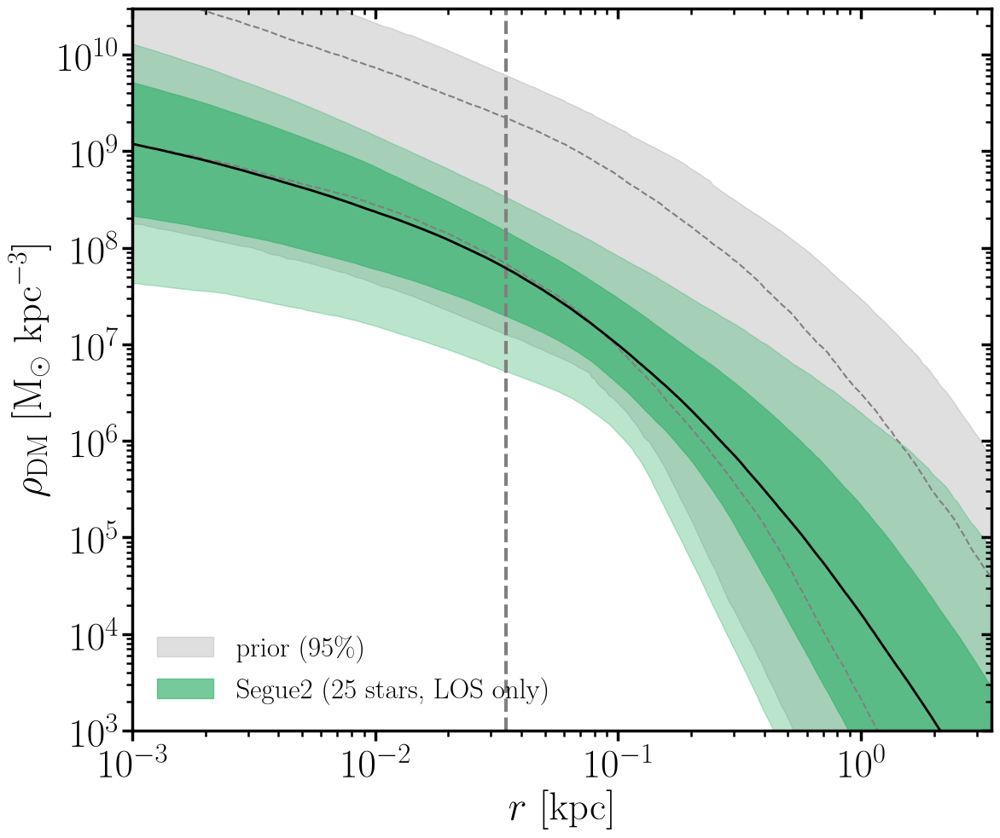

log10 rho_DM(R_half) = 7.79 -0.50 +0.38  [Msun/kpc^3]


In [6]:
#--- Segue2: DM density profile -------------------------------------------------------------

#--- prior-only rho_DM band, for comparison with the posterior -------------------------------
nprior = 2000
rng_p = np.random.default_rng(1)
iM = 2*n_betpars + nu_components


prior_den = np.zeros((nprior, len(Ra)))
for k in range(nprior):
    theta = minarr + (maxarr - minarr)*rng_p.random(ndims)   # same uniform prior as ptform
    for i in logthis:
        theta[i] = 10.0**theta[i]
    prior_den[k] = corenfw_tides_den(Ra, *theta[iM:iM+6])

bp = band(prior_den)

fig, ax = plt.subplots(figsize=(13, 11))
ax.fill_between(Ra, bp[0], bp[4], color='grey', alpha=0.25, zorder=-2, label='prior (95\%)')
ax.plot(Ra, bp[1], color='grey', ls='--', lw=1.5); ax.plot(Ra, bp[3], color='grey', ls='--', lw=1.5)




upacs = np.zeros((len(s1flat), len(Ra)))
for k in range(len(s1flat)):
    theta = np.copy(s1flat[k])
    for i in logthis:                    # exponentiate the log-sampled parameters
        theta[i] = 10.0**theta[i]
    Mppars = theta[2*n_betpars+nu_components:2*n_betpars+nu_components+6]  # coreNFWtides
    upacs[k, :] = corenfw_tides_den(Ra, *Mppars)

b = band(upacs)

ax.fill_between(Ra, b[0], b[4], color=col, alpha=0.35, zorder=-1)   # 95%
ax.fill_between(Ra, b[1], b[3], color=col, alpha=al, label=leg, zorder=-1)  # 68%
ax.plot(Ra, b[2], color='k', lw=2.0)                               # median
ax.set_xlabel(r'$r$ [kpc]', fontsize=fsl)
ax.set_ylabel(r'$\rho_{\rm DM}$ [M$_{\odot}$ kpc$^{-3}$]', fontsize=fsl)
pretty_ax(ax, 1e3, 3e10, logy=True)
ax.legend(frameon=False, fontsize=fsl*0.7, loc='lower left')
plt.savefig(str(diro + 'Plots/den_segue2.pdf'), bbox_inches='tight')
plt.show()

q = np.percentile(np.log10(upacs[:, np.argmin(np.abs(Ra - Rhalf))]), [16, 50, 84])
print('log10 rho_DM(R_half) = %.2f -%.2f +%.2f  [Msun/kpc^3]' % (q[1], q[1]-q[0], q[2]-q[1]))


NameError: name 'fsl' is not defined

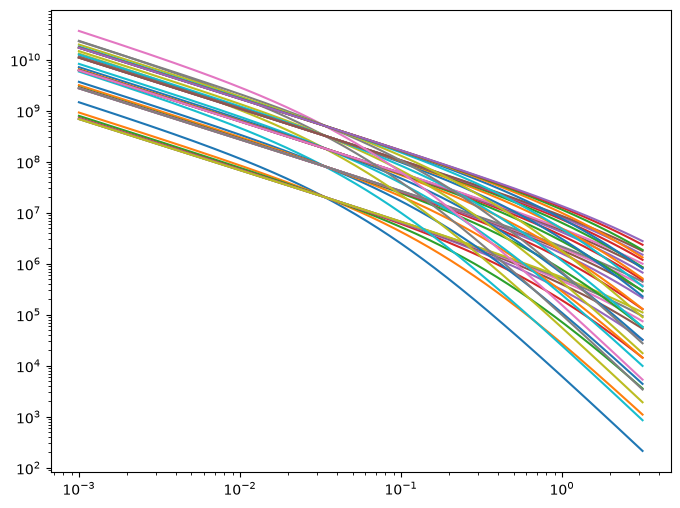

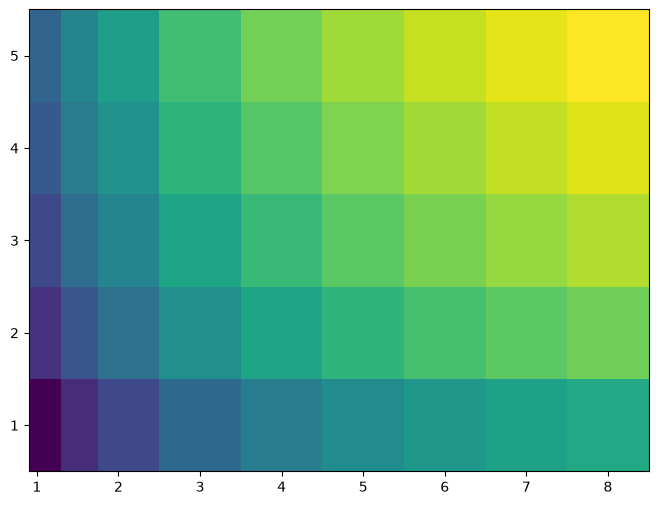

In [1]:
"""
Mean (time-averaged) NFW halo used to build the FDM wavefunction for Segue 2
in Dalal & Kravtsov (2022), arXiv:2203.05750.

Parameterisation (their Sec. II): (v_1/2, v_max), with v_max = k * v_1/2 fixed.
The paper does NOT quote k, so it is a free choice here (see sensitivity plot).
"""
import numpy as np
from scipy.optimize import brentq
import matplotlib.pyplot as plt

G = 4.30091e-3                     # pc (km/s)^2 / Msun

# --- Segue 2 inputs from the paper ---
R_half_2D = 40.5                   # pc, projected Plummer half-light radius (distance-corrected)
r_half = 1.34 * R_half_2D          # pc, 3D half-light radius (their factor 1.34)
v_half_prior = (1.0, 5.0)          # km/s, uniform prior on v_1/2 for Segue 2

m   = lambda x: np.log1p(x) - x / (1 + x)      # NFW mass function
X_MAX = brentq(lambda x: (1 + x)**2 * np.log1p(x) - x * (1 + 2 * x), 1, 3)  # 2.16258
F_MAX = m(X_MAX) / X_MAX

def nfw_params(v_half, k):
    """Return (rho_s [Msun/pc^3], r_s [pc]) given v_1/2 at r_half and v_max = k v_1/2."""
    target = F_MAX / k**2                          # m(y)/y at y = r_half / r_s
    y = brentq(lambda y: m(y) / y - target, 1e-8, X_MAX)   # inner branch: r_half < r_max
    r_s = r_half / y
    v_max = k * v_half
    rho_s = v_max**2 / (4 * np.pi * G * r_s**2 * F_MAX)
    return rho_s, r_s

H0 = 70e-6                               # km/s/pc (70 km/s/Mpc)
rho_crit = 3 * H0**2 / (8 * np.pi * G)   # Msun/pc^3 (~1.36e-7)

def rhos_rs_to_m200_c200(rho_s, r_s):
    # mean density inside r200 = 200 rho_crit  =>  m(c)/c^3 = 200 rho_crit / (3 rho_s)
    c200 = brentq(lambda c: m(c) / c**3 - 200 * rho_crit / (3 * rho_s), 1e-3, 1e5)
    M200 = 4 * np.pi * rho_s * r_s**3 * m(c200)
    return M200, c200

def rho_nfw(r, rho_s, r_s):
    x = r / r_s
    return rho_s / (x * (1 + x)**2)

r = np.logspace(0, 3.5, 400)       # 1 pc -> ~3 kpc
fig, axes = plt.subplots(figsize=(8, 6), sharey=True)
fig2, axes2 = plt.subplots(figsize=(8, 6), sharey=True)
# Left: the prior range of v_1/2 at fixed k

vh_vals = [1, 2, 3, 4, 5]
k_vals = [1.1, 1.5, 2, 3, 4, 5, 6, 7, 8]

nfw_params_plot = []
for vh in vh_vals:
    for k in k_vals:
        rs_, rss = nfw_params(vh, k)
        m200, c200 = rhos_rs_to_m200_c200(rs_, rss)
        nfw_params_plot.append((vh, k, m200, c200))
        axes.loglog(r/1000, rho_nfw(r, rs_, rss) * 1000 * 1000 * 1000)

nfw_params_plot = np.array(nfw_params_plot)

logM200 = np.log10(nfw_params_plot[:, 2]).reshape(len(vh_vals), len(k_vals))  # rows = vh, cols = k

pc = axes2.pcolormesh(k_vals, vh_vals, logM200, shading="auto", cmap="viridis")
axes2.set_xlabel("k = v_max / v_1/2", fontsize=fsl*0.7)
axes2.set_ylabel(r"$v_{1/2}$ [km/s]", fontsize=fsl*0.7)
fig2.colorbar(pc, ax=axes2, label=r"$\log_{10} M_{200}$")

axes.axvline(r_half/1000, color="grey", ls="--", lw=1, label=r"$r_{1/2}$")
axes.set_xlabel("r [kpc]", fontsize=fsl*0.7)
axes.legend(fontsize = fsl*0.7)
axes.set_ylabel(r"$\rho_{\rm NFW}$ [M$_\odot$ kpc$^{-3}$]", fontsize=fsl*0.7)
plt.tight_layout()


#--- Segue2: DM density profile -------------------------------------------------------------

ndraws = 200
rng_p = np.random.default_rng(1)
iM = 2*n_betpars + nu_components


density_draws = np.zeros((len(s1flat), len(Ra)))

for j in range(ndraws):
    random_draw = rng_p.integers(0, len(s1flat))
    theta = np.copy(s1flat[random_draw])
    for i in logthis:                    # exponentiate the log-sampled parameters
        theta[i] = 10.0**theta[i]
    Mppars = theta[2*n_betpars+nu_components:2*n_betpars+nu_components+6]  # coreNFWtides
    density_draws[j, :] = corenfw_tides_den(Ra, *Mppars)


pretty_ax(axes, ylo = 1, yhi = 1e11, xlo =1e-3, xhi = max(Ra), logy=True)
axes.plot(Ra, density_draws.T, color='k', alpha=0.1, zorder=-1)
axes.set_title('Segue 2 DM Density Profile - Gravsphere (Black) Varying v_1/2 and k (coloured)', fontsize = fsl* 0.5)
plt.show()


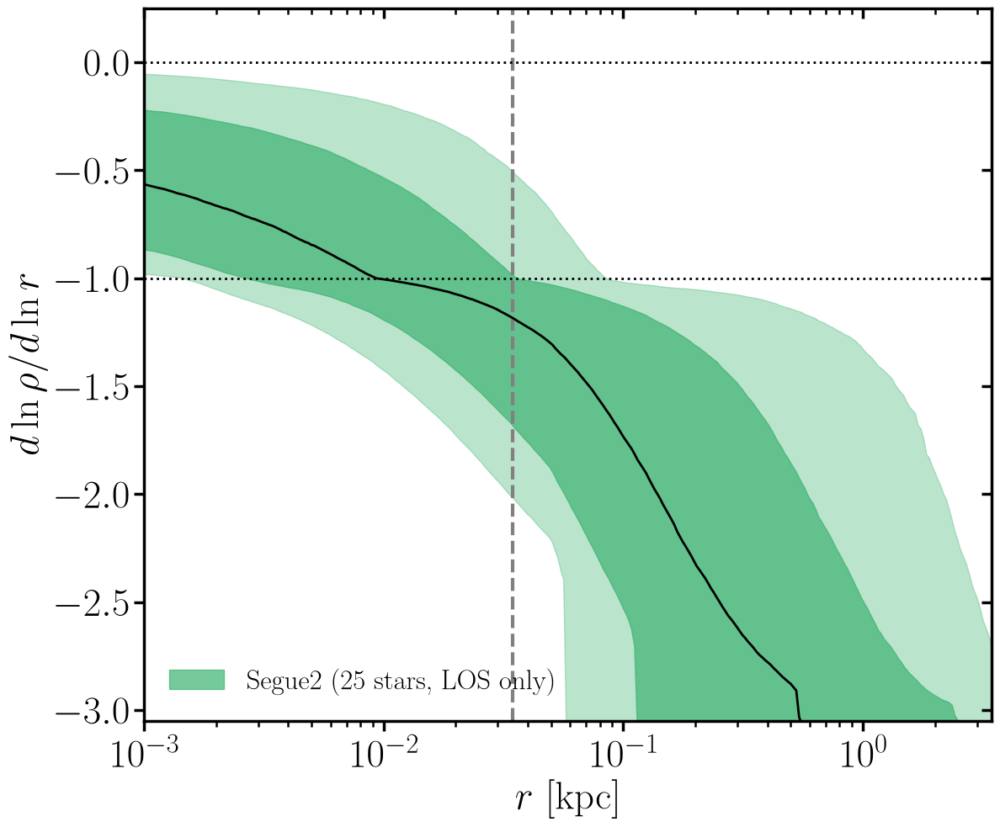

dlnrho/dlnr at r = 0.0086 kpc : -0.98 -0.17 +0.48
dlnrho/dlnr at r = 0.0173 kpc : -1.06 -0.32 +0.35
dlnrho/dlnr at r = 0.0346 kpc : -1.18 -0.50 +0.20


In [12]:
#--- Segue2: logarithmic density slope (the cusp/core diagnostic) ----------------------------

upacs = np.zeros((len(s1flat), len(Ra)))
for k in range(len(s1flat)):
    theta = np.copy(s1flat[k])
    for i in logthis:
        theta[i] = 10.0**theta[i]
    Mppars = theta[2*n_betpars+nu_components:2*n_betpars+nu_components+6]
    upacs[k, :] = corenfw_tides_dlnrhodlnr(Ra, *Mppars, dx=1e-5)

b = band(upacs)

fig, ax = plt.subplots(figsize=(13, 11))
ax.fill_between(Ra, b[0], b[4], color=col, alpha=0.35, zorder=-1)
ax.fill_between(Ra, b[1], b[3], color=col, alpha=al, label=leg, zorder=-1)
ax.plot(Ra, b[2], color='k', lw=2.0)
ax.axhline(-1.0, ls=':', color='k', lw=2.0)      # NFW cusp
ax.axhline(0.0, ls=':', color='k', lw=2.0)       # perfect core
ax.set_xlabel(r'$r$ [kpc]', fontsize=fsl)
ax.set_ylabel(r'${d \ln \rho} / {d \ln r}$', fontsize=fsl)
pretty_ax(ax, -3.05, 0.25)
ax.legend(frameon=False, fontsize=fsl*0.7, loc='lower left')
plt.savefig(str(diro + 'Plots/slope_Segue2.pdf'), bbox_inches='tight')
plt.show()

for rr in [Rhalf/4, Rhalf/2, Rhalf]:
    q = np.percentile(upacs[:, np.argmin(np.abs(Ra - rr))], [16, 50, 84])
    print('dlnrho/dlnr at r = %.4f kpc : %.2f -%.2f +%.2f' % (rr, q[1], q[1]-q[0], q[2]-q[1]))


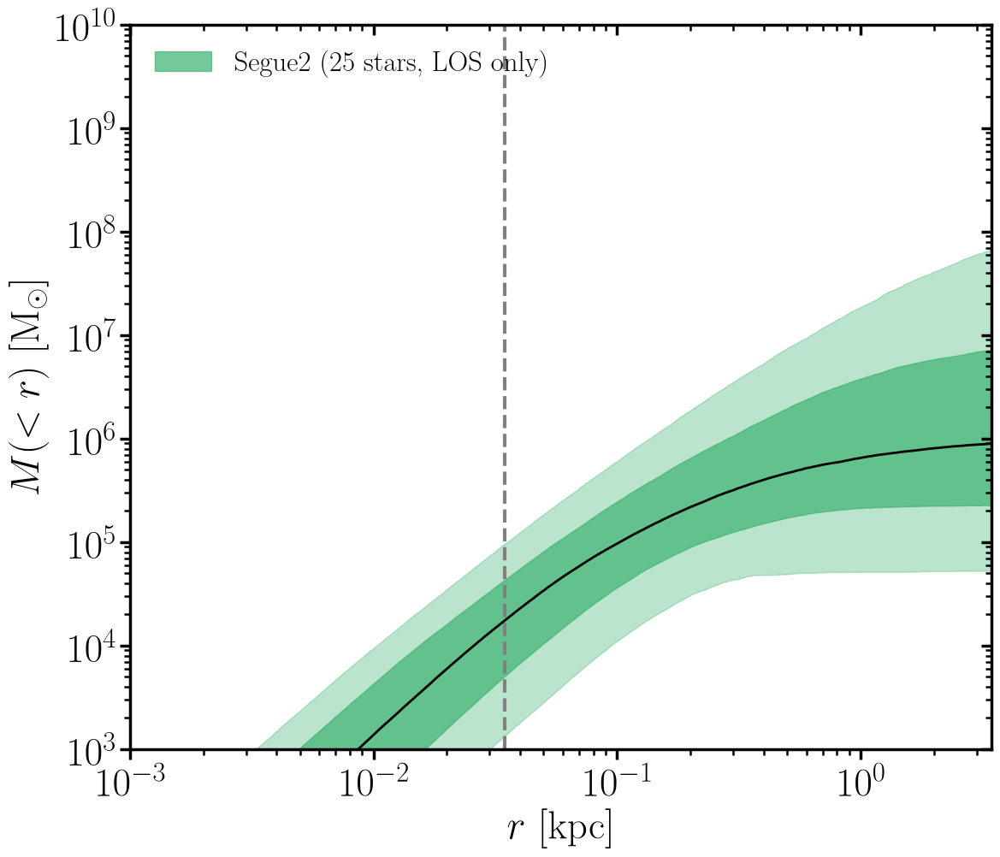

log10 M(<R_half) = 4.24 -0.54 +0.39  [Msun]


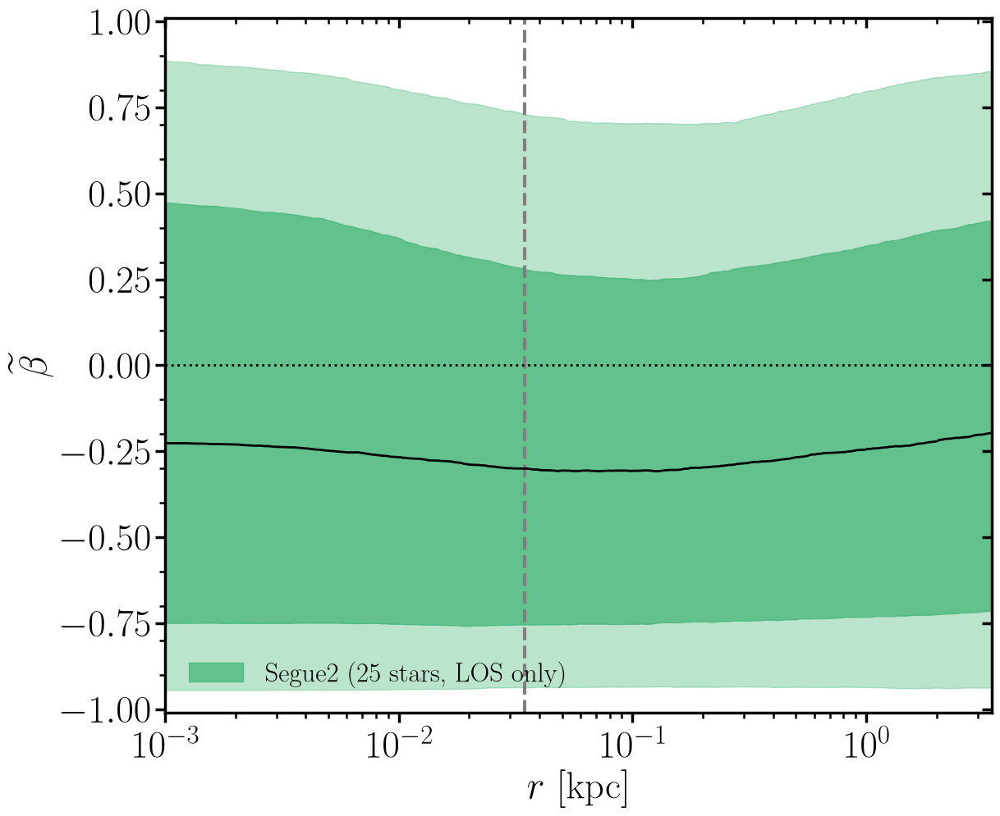

betat(R_half) = -0.30 -0.45 +0.58


In [13]:
#--- Segue2: enclosed mass, and the symmetrised anisotropy -----------------------------------

# enclosed mass
upacs = np.zeros((len(s1flat), len(Ra)))
for k in range(len(s1flat)):
    theta = np.copy(s1flat[k])
    for i in logthis:
        theta[i] = 10.0**theta[i]
    Mppars = theta[2*n_betpars+nu_components:2*n_betpars+nu_components+6]
    upacs[k, :] = corenfw_tides_mass(Ra, *Mppars)

b = band(upacs)
fig, ax = plt.subplots(figsize=(13, 11))
ax.fill_between(Ra, b[0], b[4], color=col, alpha=0.35, zorder=-1)
ax.fill_between(Ra, b[1], b[3], color=col, alpha=al, label=leg, zorder=-1)
ax.plot(Ra, b[2], color='k', lw=2.0)
ax.set_xlabel(r'$r$ [kpc]', fontsize=fsl)
ax.set_ylabel(r'$M(<r)$ [M$_{\odot}$]', fontsize=fsl)
pretty_ax(ax, 1e3, 1e10, logy=True)
ax.legend(frameon=False, fontsize=fsl*0.7, loc='upper left')
plt.savefig(str(diro + 'Plots/mass_Segue2.pdf'), bbox_inches='tight')
plt.show()

q = np.percentile(np.log10(upacs[:, np.argmin(np.abs(Ra - Rhalf))]), [16, 50, 84])
print('log10 M(<R_half) = %.2f -%.2f +%.2f  [Msun]' % (q[1], q[1]-q[0], q[2]-q[1]))

# symmetrised anisotropy  betat = beta / (2 - beta)
upacs = np.zeros((len(s1flat), len(Ra)))
for k in range(len(s1flat)):
    theta = np.copy(s1flat[k])
    theta[0] = 2.0*theta[0]/(1 + theta[0])       # symmetrised -> ordinary beta
    theta[1] = 2.0*theta[1]/(1 + theta[1])
    for i in logthis:
        theta[i] = 10.0**theta[i]
    be = beta(Ra, theta[:4])
    upacs[k, :] = be / (2 - be)

b = band(upacs)
fig, ax = plt.subplots(figsize=(13, 11))
ax.fill_between(Ra, b[0], b[4], color=col, alpha=0.35, zorder=-1)
ax.fill_between(Ra, b[1], b[3], color=col, alpha=al, label=leg, zorder=-1)
ax.plot(Ra, b[2], color='k', lw=2.0)
ax.axhline(0.0, ls=':', color='k', lw=2.0)       # isotropic
ax.set_xlabel(r'$r$ [kpc]', fontsize=fsl)
ax.set_ylabel(r'$\widetilde{\beta}$', fontsize=fsl)
pretty_ax(ax, -1.01, 1.01)
ax.set_yticks(np.arange(-1.0, 1.01, 0.1), minor=True)
ax.legend(frameon=False, fontsize=fsl*0.7, loc='lower left')

plt.show()

q = np.percentile(upacs[:, np.argmin(np.abs(Ra - Rhalf))], [16, 50, 84])
print('betat(R_half) = %.2f -%.2f +%.2f' % (q[1], q[1]-q[0], q[2]-q[1]))


In [14]:
#--- Segue2: projected sigma_LOS and kurtosis (LOS only -> sigp_k, not sigp_prop_k) ----------

nls = 500        # number of random posterior draws; raise for smoother envelopes
s1file = 'Seg2'

upacsl = np.zeros((nls, len(Ra)))    # sigma_LOS
upacslk = np.zeros((nls, len(Ra)))   # kappa_LOS

for it in range(nls):
    theta = np.copy(s1flat[np.random.randint(len(s1flat))])

    # symmetrised -> ordinary anisotropy, 2nd and 4th order
    theta[0] = 2.0*theta[0]/(1 + theta[0])
    theta[1] = 2.0*theta[1]/(1 + theta[1])
    theta[4] = 2.0*theta[4]/(1 + theta[4])
    theta[5] = 2.0*theta[5]/(1 + theta[5])
    for i in logthis:
        theta[i] = 10**theta[i]

    surc = theta[2*n_betpars:2*n_betpars+nu_components]     # tracer light profile
    if individual == True:
        surc = np.append(np.array([1.0]), surc)             # rho0 is unconstrained, set to 1

    rhobs = alpbetgamden(nu_rad, *surc)
    sobs = alpbetgamsurf(nu_rad, *surc, bar_pnts)

    def baranr(r):                                          # tracer 3D density
        return np.interp(r, nu_rad, rhobs, right=1e-30)

    def barsurf(r):                                         # tracer 2D density
        return np.interp(r, nu_rad, sobs, right=1e-30)

    Mpars = theta[2*n_betpars+nu_components:2*n_betpars+nu_components+6]

    def M(r, Mparsu):                                       # Mstar = 0 for Segue 1
        M200, c, rc, n, rt, delta = Mparsu
        return corenfw_tides_mass(r, M200, c, rc, n, rt, delta)

    Sigout, los2, kl, neg = sigp_k(np.array([1.0]), Ra, baranr, barsurf, M, beta, betaf,
                                   Mpars, theta[:4], theta[4:8], rmin, rmax, nonn=rcn)

    upacsl[it, :] = los2**0.5/1e3
    upacslk[it, :] = kl

np.savetxt(str(diro + s1file + '_sl.txt'), band(upacsl))
np.savetxt(str(diro + s1file + '_kl.txt'), band(upacslk))
print('done -> ' + diro + s1file + '_{sl,kl}.txt')


done -> /gpfs/home/jd925/GravSphere2/Output/Segue2/Seg2_{sl,kl}.txt


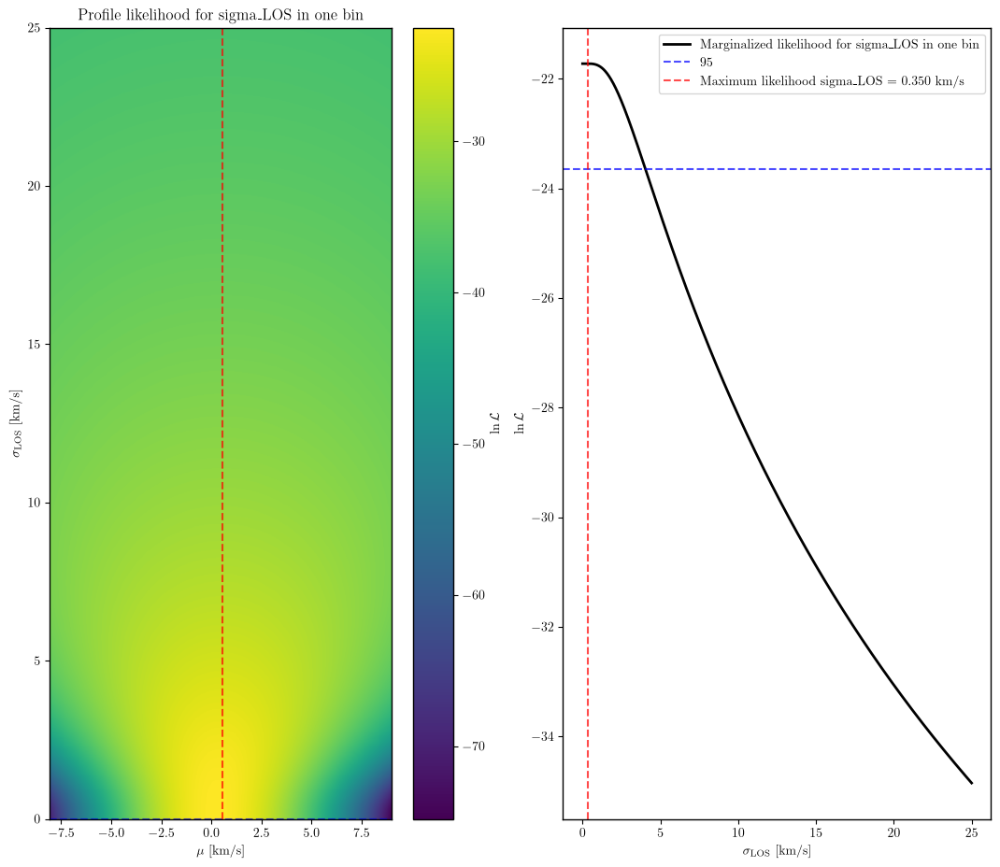

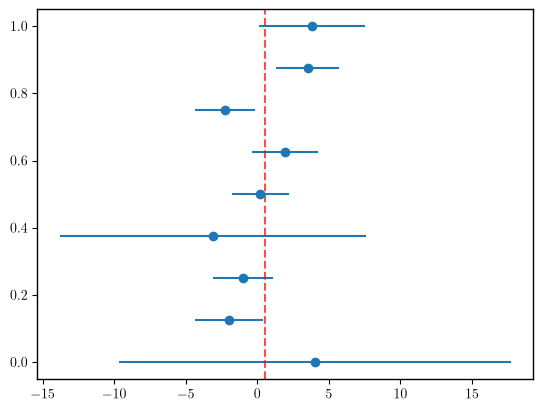

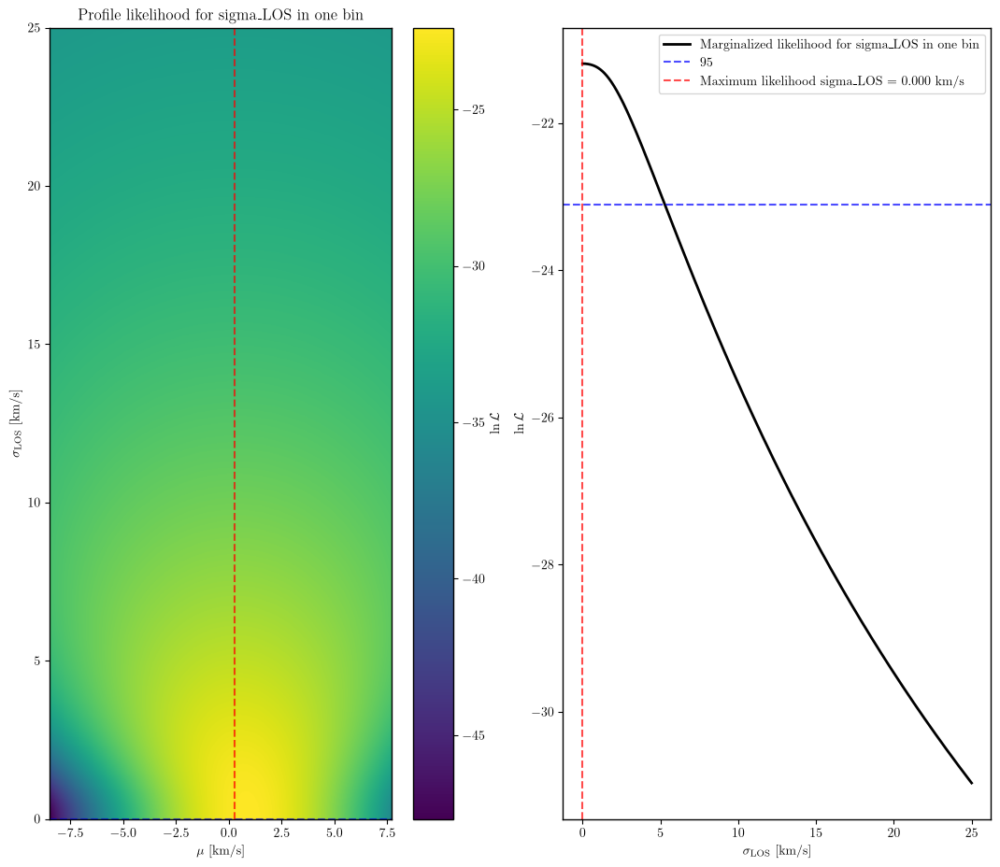

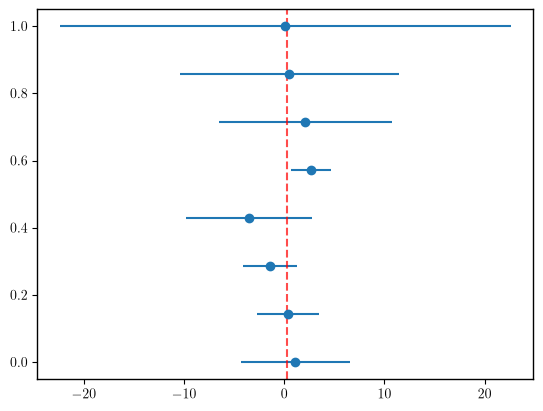

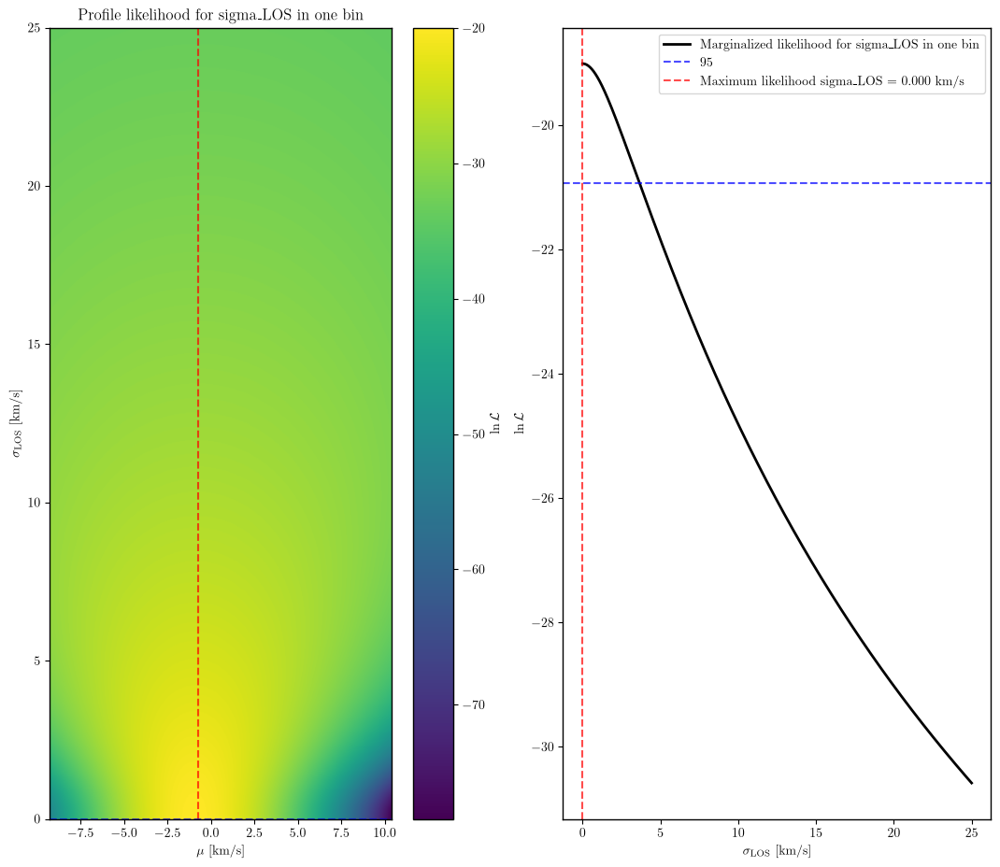

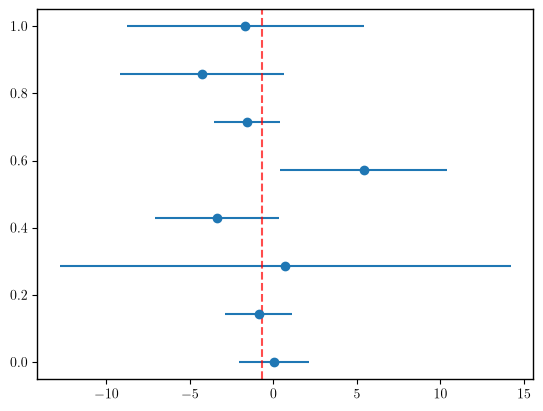

[0.35 0.   0.  ]


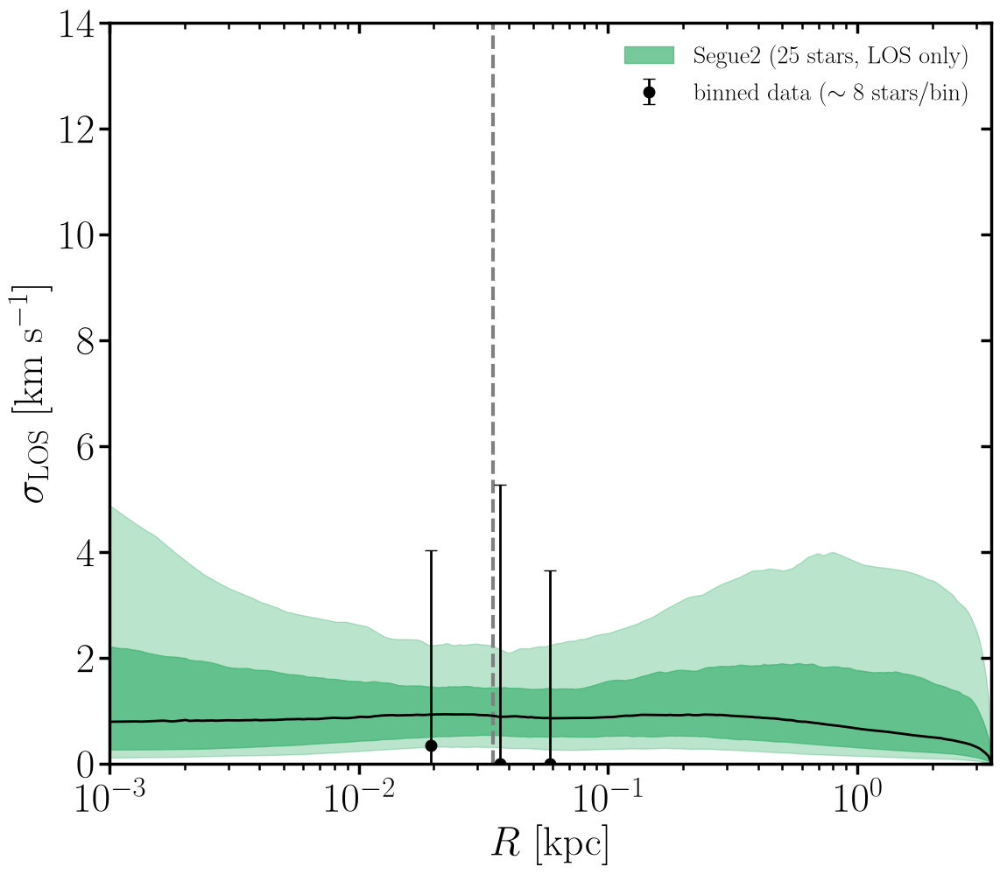

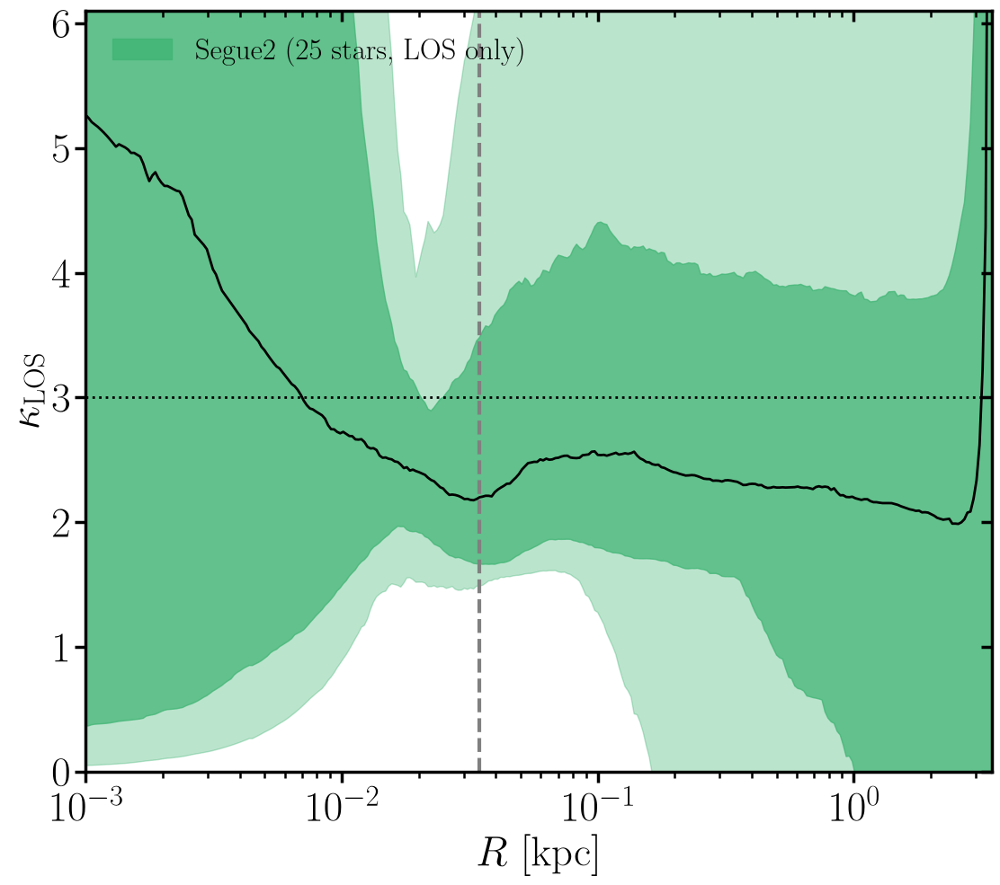

In [15]:
#--- Segue2: sigma_LOS and kappa_LOS, with binned data over-plotted --------------------------

nbin = 3
sgrid = np.linspace(0.0, 25.0, 1001)

def sig_ml(v, e):
    """Max-likelihood sigma in one bin, plus the 95% upper limit from the profile
    likelihood (Delta lnL = -1.92), systemic velocity profiled out on a grid."""
    mug = np.linspace(v.min()-5, v.max()+5, 400)
    var = sgrid[:, None, None]**2 + e[None, None, :]**2
    d2 = (v[None, None, :] - mug[None, :, None])**2

    total_lnL = (-0.5*np.sum(d2/var + np.log(2*np.pi*var), axis=2))

    fig, ax = plt.subplots(1,2, figsize=(13, 11))

    im = ax[0].imshow(total_lnL, extent=[mug.min(), mug.max(), sgrid.min(), sgrid.max()],
                  aspect='auto', origin='lower', cmap='viridis')
    fig.colorbar(im, ax=ax[0], label=r'$\ln \mathcal{L}$')

    ax[0].axvline(v.mean(), color = 'red', label = f'Mean v_LOS = {v.mean():.3f} km/s', linestyle = '--', alpha = 0.7)
    ax[0].axhline(sgrid[np.argmax(total_lnL.max(axis=1))], color = 'blue', label = f'Maximum likelihood sigma_LOS = {sgrid[np.argmax(total_lnL.max(axis=1))]:.3f} km/s', linestyle = '--', alpha = 0.7)
    ax[0].set_xlabel(r'$\mu$ [km/s]')
    ax[0].set_ylabel(r'$\sigma_{\rm LOS}$ [km/s]')
    ax[0].set_title('Profile likelihood for sigma_LOS in one bin')

    #Integrating over mu to get the marginalized likelihood for sigma_LOS
    dmu = np.diff(mug)[0]
    lnL_sig = np.log(np.sum(np.exp(total_lnL)*dmu, axis=1))

    ax[1].plot(sgrid, lnL_sig, color='k', lw=2.0, label = f'Marginalized likelihood for sigma_LOS in one bin')
    ax[1].axhline(lnL_sig.max() - 1.92, color = 'blue', label = f'95% upper limit = {sgrid[np.where(lnL_sig >= lnL_sig.max() - 1.92)[0].max()]:.3f} km/s', linestyle = '--', alpha = 0.7)
    ax[1].axvline(sgrid[np.argmax(lnL_sig)], color = 'red', label = f'Maximum likelihood sigma_LOS = {sgrid[np.argmax(lnL_sig)]:.3f} km/s', linestyle = '--', alpha = 0.7)
    ax[1].set_xlabel(r'$\sigma_{\rm LOS}$ [km/s]')
    ax[1].set_ylabel(r'$\ln \mathcal{L}$')
    ax[1].legend()
    plt.show()

    y = np.linspace(0, 1, len(v))
    plt.errorbar(v, y=y, xerr = e, yerr = 0.0, fmt = 'o')
    plt.axvline(v.mean(), color = 'red', label = f'Mean v_LOS = {v.mean():.3f} km/s', linestyle = '--', alpha = 0.7)
    plt.show()


    lnL_sig -= lnL_sig.max()
    s_ml = sgrid[np.argmax(lnL_sig)]
    s_up = sgrid[np.where(lnL_sig >= -1.92)[0].max()]
    return s_ml, s_up

star_data = np.loadtxt('/gpfs/home/jd925/GravSphere2/Data/Seg2/Seg2_Rproj_vlos_vloserr.txt')
r_, v_, e_ = star_data.T
idx = np.argsort(r_)
Rs, vs, es = r_[idx], v_[idx], e_[idx]

groups = np.array_split(np.arange(len(Rs)), nbin)
Rb = np.array([Rs[g].mean() for g in groups])
res = np.array([sig_ml(vs[g], es[g]) for g in groups])
sb, sb_up = res[:, 0], res[:, 1]
sberr = np.vstack([sb_up - sb, sb_up - sb])   # one-sided: ML point up to 95% upper limit
print(sb)
# sigma_LOS
b = np.loadtxt(str(diro + s1file + '_sl.txt'))
fig, ax = plt.subplots(figsize=(13, 11))
ax.fill_between(Ra, b[0], b[4], color=col, alpha=0.35, zorder=-1)
ax.fill_between(Ra, b[1], b[3], color=col, alpha=al, label=leg, zorder=-1)
ax.plot(Ra, b[2], color='k', lw=2.0)
ax.errorbar(Rb, sb, yerr=sberr, fmt='o', color='k', ms=9, capsize=5, lw=2.0, zorder=5,
            label=r'binned data ($\sim %d$ stars/bin)' % (len(Rs)//nbin))
ax.set_xlabel(r'$R$ [kpc]', fontsize=fsl)
ax.set_ylabel(r'$\sigma_{\rm LOS}$ [km s$^{-1}$]', fontsize=fsl)
pretty_ax(ax, 0.0, 14.0)
ax.legend(frameon=False, fontsize=fsl*0.6, loc='upper right')
plt.savefig(str(diro + 'Plots/sl_Segue2.pdf'), bbox_inches='tight')
plt.show()

# kappa_LOS
b = np.loadtxt(str(diro + s1file + '_kl.txt'))
fig, ax = plt.subplots(figsize=(13, 11))
ax.fill_between(Ra, b[0], b[4], color=col, alpha=0.35, zorder=-1)
ax.fill_between(Ra, b[1], b[3], color=col, alpha=al, label=leg, zorder=-1)
ax.plot(Ra, b[2], color='k', lw=2.0)
ax.axhline(3.0, ls=':', color='k', lw=2.0)       # Gaussian
ax.set_xlabel(r'$R$ [kpc]', fontsize=fsl)
ax.set_ylabel(r'$\kappa_{\rm LOS}$', fontsize=fsl)
pretty_ax(ax, 0.0, 6.1)
ax.legend(frameon=False, fontsize=fsl*0.7, loc='upper left')
plt.savefig(str(diro + 'Plots/kl_Segue2.pdf'), bbox_inches='tight')
plt.show()


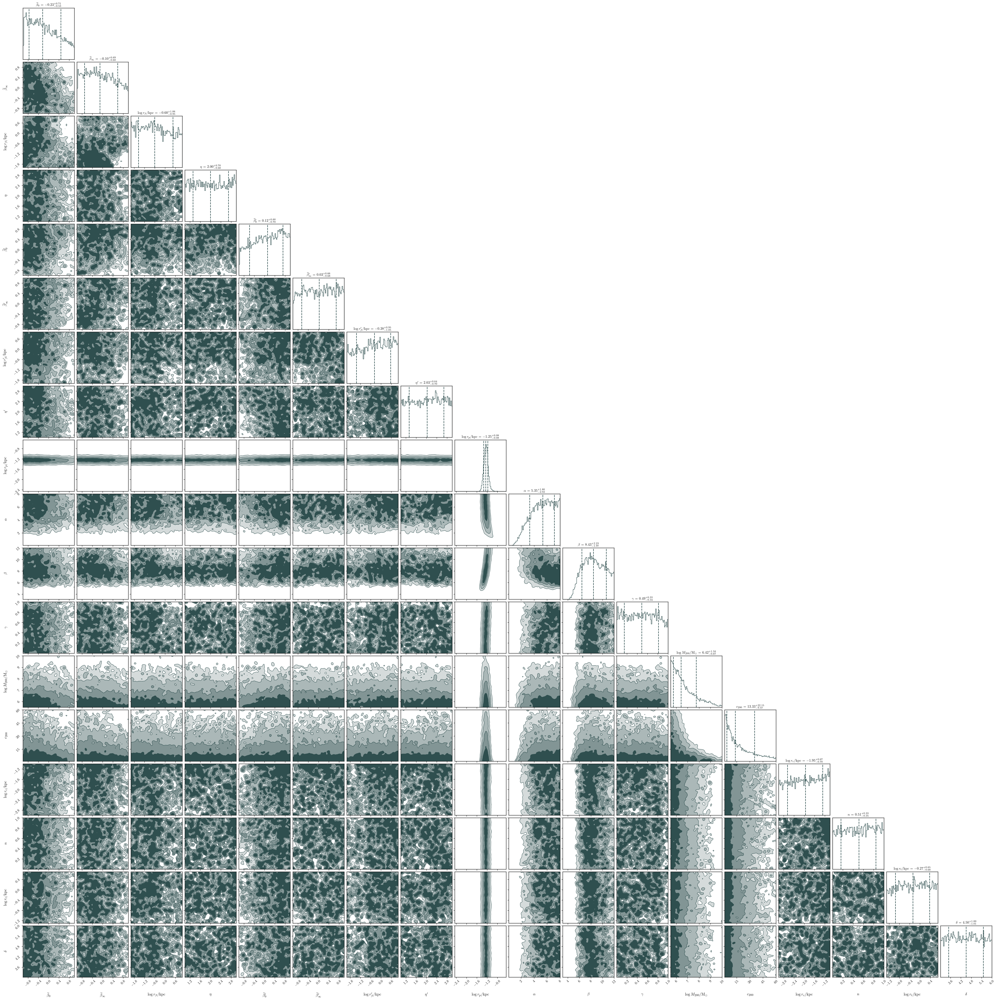

In [16]:
#--- Segue2: corner plot ----------------------------------------------------------------------

import corner

labes = [r'$\widetilde \beta_0$', r'$\widetilde \beta_{\infty}$',
         r'$\log r_{\beta}$/kpc', r'$\eta$',
         r"$\widetilde \beta_0'$", r"$\widetilde \beta_{\infty}'$",
         r"$\log r_{\beta}'$/kpc", r"$\eta'$",
         r'$\rho_{p}$/kpc$^{-3}$', r'$r_p$/kpc',
         r'$\alpha$', r'$\beta$', r'$\gamma$',
         r'$\log M_{200}$/M$_{\odot}$', r'$c_{200}$',
         r'$\log r_c$/kpc', r'$n$', r'$\log r_t$/kpc', r'$\delta$']

if individual == True:
    labes[9] = r'$\log r_p$/kpc'   # log-priors on rp in the individual-tracer case
    labes.pop(2*n_betpars)         # rho_p is not a free parameter, drop its label

levs = (1 - np.exp(-(1)**2/2), 1 - np.exp(-(1.5)**2/2),
        1 - np.exp(-(2.0)**2/2), 1 - np.exp(-(2.5)**2/2))

seq = resu.samples_equal()
rng = [(minarr[i], maxarr[i]) for i in range(ndims)]   # show the full prior box:
                                                       # flat-topped 1D panels = prior-limited
if Mstar != 0.0:
    # Mstar is the last dimension and is sampled linearly in [Mstar_min, Mstar_max];
    # plot it in log, and put its prior box in log too, or corner histograms the
    # log-samples inside a linear-Msun range and gets an empty 2D histogram.
    labes.append(r'$\log M_{\star}$ [M$_{\odot}$]')
    seq[:, -1] = np.log10(seq[:, -1])
    rng[-1] = (np.log10(minarr[-1]), np.log10(maxarr[-1]))

fig = corner.corner(seq, labels=labes,
    quantiles=(0.16, 0.5, 0.84), label_kwargs=dict(fontsize=11),
    show_titles=True, title_fmt='.2f', use_math_text=True, title_kwargs=dict(fontsize=10),
    bins=70, smooth=1.4, fill_contours=True, color='darkslategray',
    plot_datapoints=False, plot_density=False,
    contour_kwargs={'linewidths': 0.8}, levels=levs,
    range=rng)

plt.savefig(str(diro + 'Plots/corner_Segue2.pdf'), bbox_inches='tight')
plt.show()


# Plots for comparison with simulations

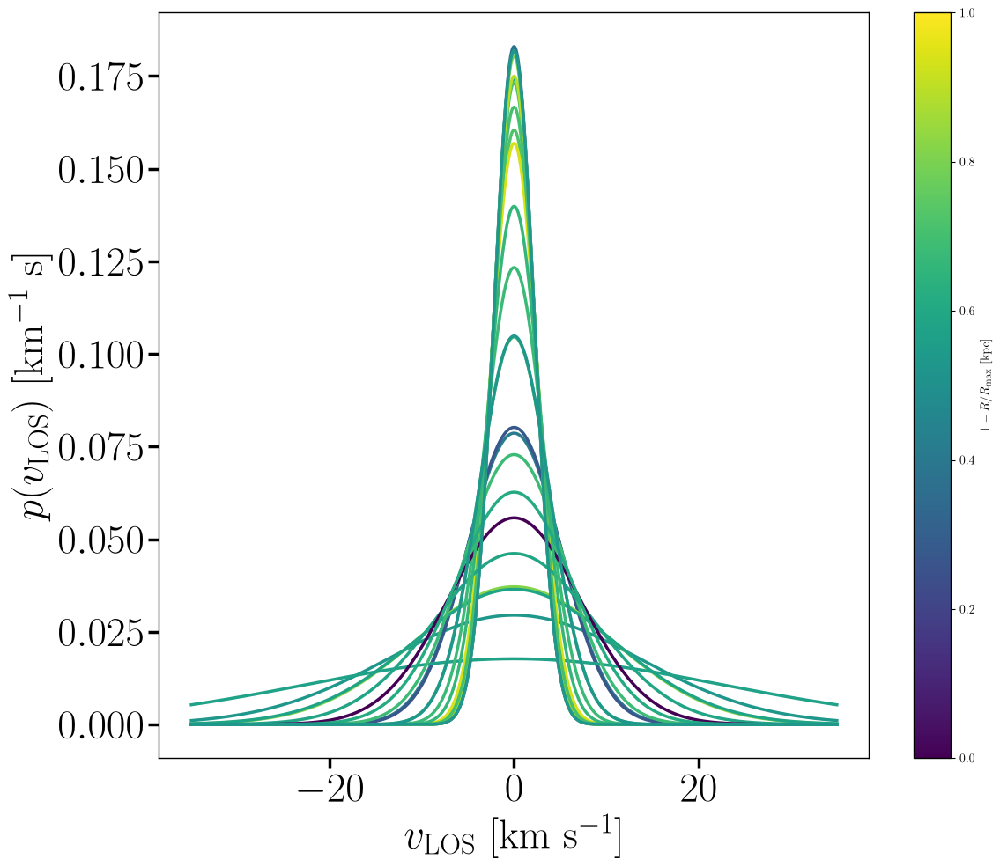

In [17]:
#--- Segue2: LOS velocity distributions from Eqs. A.1 / A.6 ---------------------------------
from scipy.special import ndtr, erfc          # ndtr = Phi, the standard normal CDF (Eq. A.2)

aguess = np.linspace(1e-6, 100, 10**4)

def get_a(kurt):

    if kurt < 3.0:
        kg = 3.0 - (2*aguess**4/15)*(1 + aguess**2/3)**(-2.0)              # A.4
        return np.interp(kurt, kg[::-1], aguess[::-1])
    else:
        kg = 3.0 + 12*aguess**4*(2*aguess**2 + 1)**(-2.0)                      # A.7
        return np.interp(kurt, kg, aguess)

def fvel(v, sigma, kurt, err):
    
    w = np.asarray(v, dtype=float)/sigma
    s = err/sigma

    if abs(kurt - 3.0) < 1e-4:                                       # a -> 0: Gaussian limit
        t = np.sqrt(1.0 + s**2)
        return np.exp(-0.5*(w/t)**2)/(np.sqrt(2*np.pi)*t)/sigma
    
    a = get_a(kurt)
    if kurt < 3.0:
        b = np.sqrt(1.0 + a**2/3.0)                                  # A.5
        t = np.sqrt(1.0 + b**2*s**2)                                 # A.3
        f = b/(2*a)*(ndtr((b*w + a)/t) - ndtr((b*w - a)/t))          # A.1
    else:
        b = np.sqrt(2.0*a**2 + 1.0)                                  # A.8
        t = np.sqrt(1.0 + b**2*s**2)                          # A.3
        f = b/(4*a)*(np.exp((t**2 - 2*a*b*w)/(2*a**2))*erfc((t**2 - a*b*w)/(np.sqrt(2)*t*a))
                   + np.exp((t**2 + 2*a*b*w)/(2*a**2))*erfc((t**2 + a*b*w)/(np.sqrt(2)*t*a)))  # A.6
    return f/sigma

n_prof = len(rLOS)
Rshow  = rLOS
R_max = np.max(Rshow)

sl     = np.loadtxt(str(diro + s1file + '_sl.txt'))[2]
kl     = np.loadtxt(str(diro + s1file + '_kl.txt'))[2]
sig_at = np.interp(Rshow, Ra, sl)
kur_at = np.interp(Rshow, Ra, kl)

star_data = np.loadtxt('/gpfs/home/jd925/GravSphere2/Data/Seg2/Seg2_Rproj_vlos_vloserr.txt')

vLOS_err = star_data[:, 2]

vv = np.linspace(-35.0, 35.0, 1000)
fig, ax = plt.subplots(figsize=(13, 11))
for i, (R, s, k) in enumerate(zip(Rshow, sig_at, kur_at)):
    err = vLOS_err[i]
    ax.plot(vv, fvel(vv, s, k, err), color=plt.cm.viridis(1 - R/R_max), lw=2.5,
            ls='-', label=r'$R = %.1f$ pc' % (1e3*R))

ax.colorbar = plt.colorbar(plt.cm.ScalarMappable(cmap='viridis'),
                          ax=ax, orientation='vertical', label=r'$1 - R/R_{\max}$ [kpc]')
ax.set_xlabel(r'$v_{\rm LOS}$ [km s$^{-1}$]', fontsize=fsl)
ax.set_ylabel(r'$p(v_{\rm LOS})$ [km$^{-1}$ s]', fontsize=fsl)
ax.tick_params(labelsize=fst)
ax.tick_params('both', length=8.5, width=2.5, which='major', direction='out')
#ax.legend(frameon=False, fontsize=fsl*0.45, ncol=2)
plt.savefig(str(diro + 'Plots/vdf_Segue2.pdf'), bbox_inches='tight')
plt.show()


R_proj range = 0.0056 - 0.0983 kpc   (R_half = 0.0346 kpc)


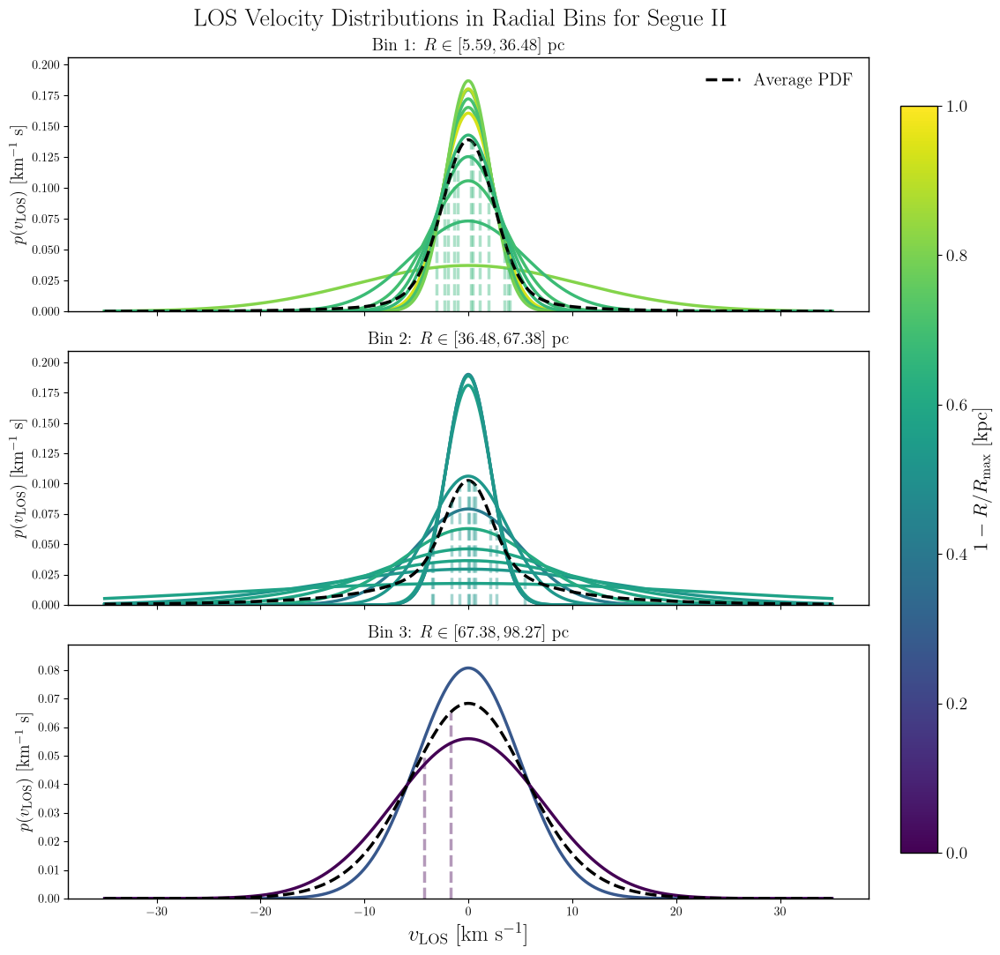

In [41]:
n_bins = 3

rLOS = star_data[:, 0]

print('R_proj range = %.4f - %.4f kpc   (R_half = %.4f kpc)' % (rLOS.min(), rLOS.max(), Rhalf))

bin_edges = np.linspace(rLOS.min(), rLOS.max(), n_bins + 1)

fig, ax = plt.subplots(n_bins, 1, sharex=True, figsize=(13, 11))

for i in range(n_bins):
    mask = (rLOS >= bin_edges[i]) & (rLOS <= bin_edges[i + 1])

    if sum(mask) == 0:
        print('Bin %d: no stars in range [%.2f, %.2f] kpc' % (i + 1, bin_edges[i], bin_edges[i + 1]))
        continue

    bin_rLOS = rLOS[mask]
    bin_vLOS = star_data[mask, 1]
    bin_vLOS_err = star_data[mask, 2]
    sig_at_bin = sig_at[mask]
    kur_at_bin = kur_at[mask]

    vv = np.linspace(-35.0, 35.0, 1000)

    max_pdf = 0.0

    for j, (R, s, k) in enumerate(zip(bin_rLOS, sig_at_bin, kur_at_bin)):
        err = bin_vLOS_err[j]


        ax[i].plot(vv, fvel(vv, s, k, err), color=plt.cm.viridis(1 - R/R_max), lw=2.5,
                   ls='-')

        max_pdf = np.nanmax([np.max(fvel(vv, s, k, err)), max_pdf])



    average_pdf = np.nanmean([fvel(vv, s, k, err) for s, k, err in zip(sig_at_bin, kur_at_bin, bin_vLOS_err)], axis=0)

    ax[i].plot(vv, average_pdf, color='k', lw=2.5, ls='--', label='Average PDF')

    for j in range(len(bin_vLOS)):

        ax[i].vlines(x = bin_vLOS[j], ymax = average_pdf[np.argmin(abs(vv - bin_vLOS[j]))], ymin = 0, color=plt.cm.viridis(1 - R/R_max), lw=2.5, ls='--', alpha = 0.4)


    ax[i].set_ylabel(r'$p(v_{\rm LOS})$ [km$^{-1}$ s]', fontsize=14)
    ax[i].set_title(r'Bin %d: $R \in [%.2f, %.2f]$ pc' % (i + 1, bin_edges[i]*1000, bin_edges[i + 1]*1000), fontsize=14)
    if i == 0:
        ax[i].legend(frameon=False, fontsize=14)


    ax[i].set_ylim(0, max_pdf * 1.1)

ax[-1].set_xlabel(r'$v_{\rm LOS}$ [km s$^{-1}$]', fontsize=18)
fig.suptitle('LOS Velocity Distributions in Radial Bins for Segue II', fontsize=20, x=0.4)
cbar = fig.colorbar = plt.colorbar(plt.cm.ScalarMappable(cmap='viridis'),
                          ax=ax, orientation='vertical', pad = -0.45)

cbar.ax.tick_params(labelsize=14) 
cbar.set_label(r'$1 - R/R_{\max}$ [kpc]', size=16)

plt.tight_layout()
plt.show()

    




r_p       0.057 -0.010 +0.012
alpha     5.291 -2.064 +1.858
beta      8.518 -2.021 +2.184
gamma     0.471 -0.311 +0.339


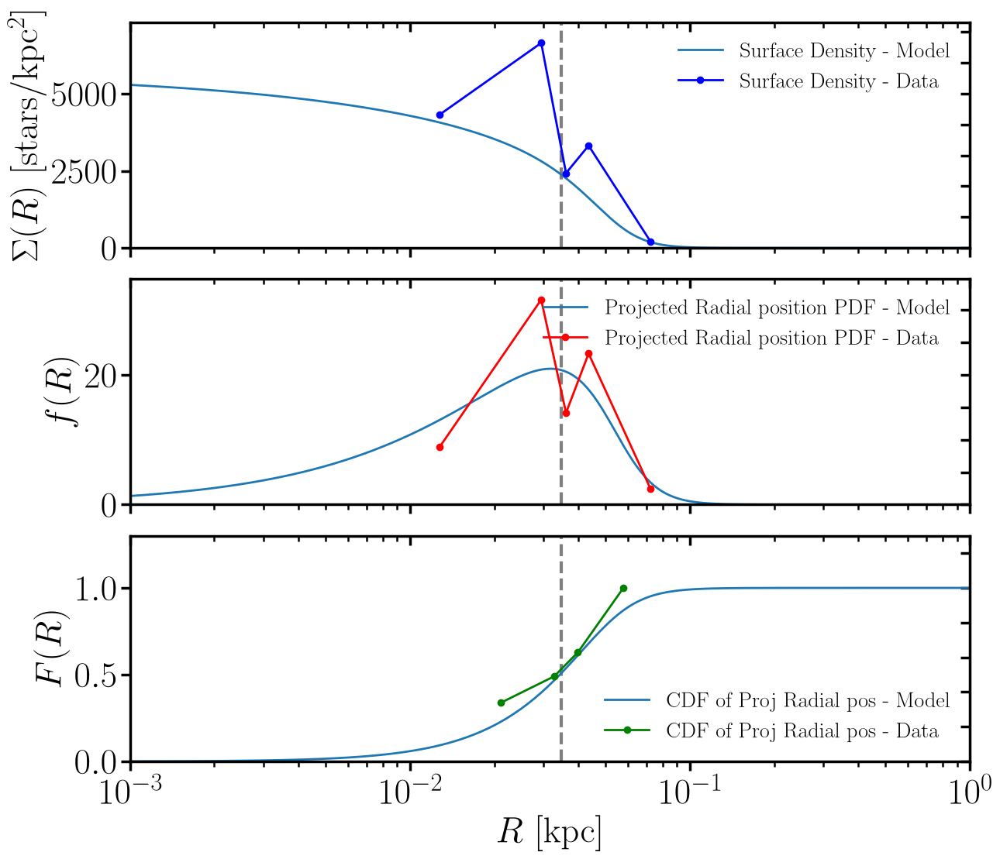

In [42]:
# Sigma model

from scipy.special import gamma as gammafn

i_nu = 2*n_betpars                      # = 8, first light-profile column

rp_s  = 10.0**s1flat[:, i_nu]           # kpc  (log-sampled -> exponentiate)
alp_s = s1flat[:, i_nu + 1]
bet_s = s1flat[:, i_nu + 2]
gam_s = s1flat[:, i_nu + 3]

r_p, alp_p, bet_p, gam_p = (np.median(rp_s), np.median(alp_s),
                            np.median(bet_s), np.median(gam_s))

for nm, x in [('r_p', rp_s), ('alpha', alp_s), ('beta', bet_s), ('gamma', gam_s)]:
    q = np.percentile(x, [16, 50, 84])
    print('%-6s %8.3f -%.3f +%.3f' % (nm, q[1], q[1]-q[0], q[2]-q[1]))


rrp = Ra/r_p

rho_p = 1

nu_star = rho_p / ((rrp)**gam_p * (1 + (rrp)**alp_p)**((bet_p - gam_p)/alp_p))

def Sigma_abg(R, rho0, r0, alp, bet, gam, npts=2000, zmax=200.0):
    R = np.atleast_1d(R)
    z = np.logspace(-6, np.log10(zmax), npts)[None, :]      # kpc
    rr = np.sqrt(R[:, None]**2 + z**2)
    return 2.0*np.trapezoid(alpbetgamden(rr, rho0, r0, alp, bet, gam), z, axis=1)


def abg_normmass(r0, alp, bet, gam, rho0=1.0):
    return (4*np.pi*rho0*r0**3 * gammafn((bet - 3)/alp) * gammafn((3 - gam)/alp)
            / (gammafn((bet - gam)/alp) * alp))

N_stars = len(rLOS)
rho_p   = N_stars / abg_normmass(r_p, alp_p, bet_p, gam_p)   # stars kpc^-3

Sigma_model = Sigma_abg(Ra, rho_p, r_p, alp_p, bet_p, gam_p)


f_pos_model = Ra * Sigma_model / (np.trapezoid(Ra * Sigma_model, Ra))



# Plot Sigma(R) (surface density) from data

rLOS = star_data[:, 0]
rLOS_sorted = sorted(rLOS)

n_bins = 5
no_of_stars_per_bin = len(rLOS) / n_bins

Sigma = []
bin_centers = []

for i in range(n_bins):

    bin_l_edge = rLOS_sorted[0 + int(i*no_of_stars_per_bin)]
    bin_r_edge = rLOS_sorted[4 + int(i*no_of_stars_per_bin)]
    bin_centers.append((bin_l_edge + bin_r_edge) / 2)


    Sigma.append(no_of_stars_per_bin / (np.pi * (bin_r_edge**2 - bin_l_edge**2)))

Sigma = np.array(Sigma)
bin_centers = np.array(bin_centers)

fig, ax = plt.subplots(3, 1, figsize=(13, 11), sharex=True)

ax[0].plot(Ra, Sigma_model, lw = 2, label=r'Surface Density - Model')


ax[0].plot(bin_centers, Sigma, 'o-', color='blue', lw=2.0, label='Surface Density - Data')

ax[0].set_ylabel(r'$\Sigma(R)$ [stars/kpc$^2$]', fontsize=fsl)

pretty_ax(ax[0], ylo = 0.0, xlo = 1*10**(-3), xhi = 1, yhi = np.max(Sigma[~np.isnan(Sigma)]) * 1.1)
ax[0].legend(frameon=False, fontsize=fsl*0.6, loc='upper right')


bin_centers = bin_centers[~np.isnan(Sigma)]
Sigma = Sigma[~np.isnan(Sigma)]



f_pos = bin_centers * Sigma / (np.trapezoid(bin_centers * Sigma, bin_centers))

ax[1].plot(Ra, f_pos_model, lw = 2, label='Projected Radial position PDF - Model')

ax[1].plot(bin_centers, f_pos, 'o-', color='red', lw=2.0, label='Projected Radial position PDF - Data')
ax[1].set_ylabel(r'$f(R)$', fontsize=fsl)
pretty_ax(ax[1], 0.0, xlo = 1*10**(-3), xhi = 1, yhi = np.max(f_pos) * 1.1)
ax[1].legend(frameon=False, fontsize=fsl*0.6, loc='upper right')



ax[2].plot(Ra, np.cumsum(f_pos_model * np.gradient(Ra)), lw = 2, label = 'CDF of Proj Radial pos - Model')



avg_int = 0.5 * (f_pos[1:] + f_pos[:-1])

avg_int_start = 0.5 * (0 + f_pos[0])

dr = np.diff(bin_centers)

answer = np.cumsum(avg_int * dr)

bin_centers = 0.5 * (bin_centers[1:] + bin_centers[:-1])

ax[2].plot(bin_centers, answer, 'o-', lw = 2, label = 'CDF of Proj Radial pos - Data', c = 'green')
pretty_ax(ax[2], 0, xlo = 1*10**(-3), xhi = 1, yhi = 1.3)
ax[2].set_xlabel(r'$R$ [kpc]', fontsize=fsl)
ax[2].set_ylabel(r'$F(R)$', fontsize=fsl)
ax[2].legend(frameon=False, fontsize = fsl*0.6, loc='lower right')

plt.tight_layout()
plt.show()



200 / 200 draws kept


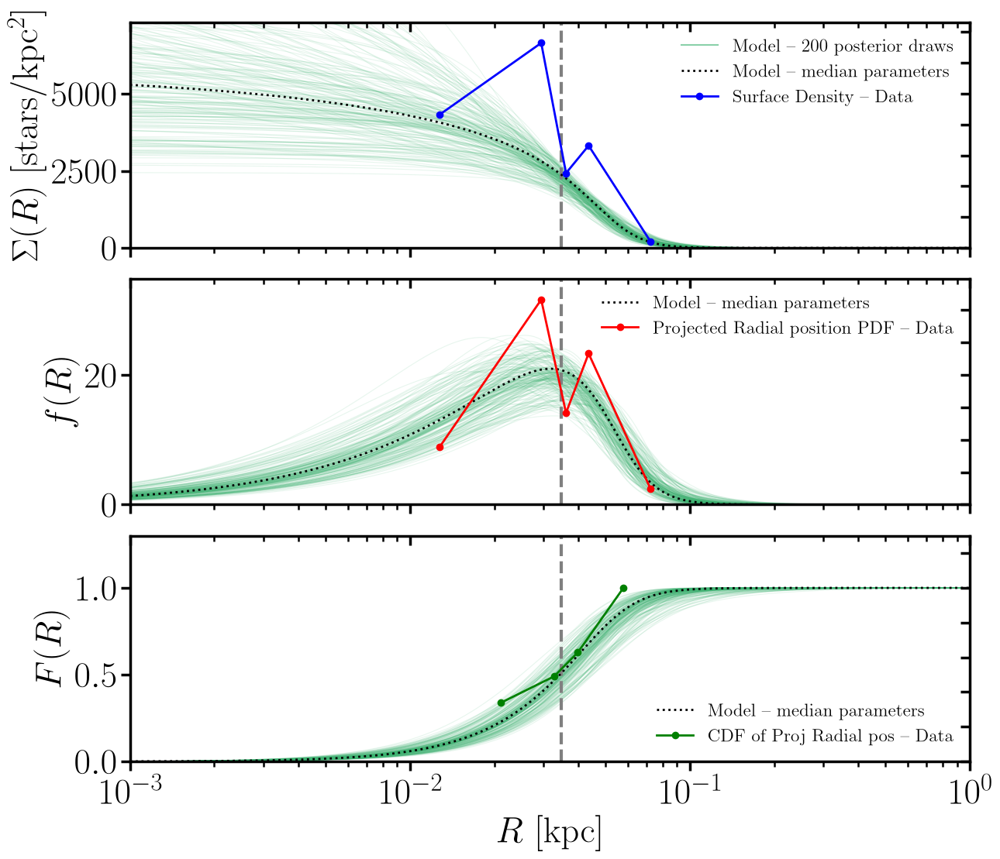

Sigma(R_half) = 2.25e+03 -303 +216  [stars/kpc^2]


In [43]:
#--- Segue2: Sigma(R) from posterior draws of the light-profile parameters ---------------------
# Same model as the cell above, but instead of a single curve at the median parameters we
# draw n_draw parameter sets from the posterior and propagate each one through Sigma(R),
# f(R) and F(R).  The thick black line is the mean over the draws (the median-parameter
# curve is kept for reference), the thin lines are the individual draws.

n_draw = 200
rng_draw = np.random.default_rng(42)
idx_draw = rng_draw.choice(len(s1flat), size=min(n_draw, len(s1flat)), replace=False)

Sigma_draws = np.zeros((len(idx_draw), len(Ra)))
for j, k in enumerate(idx_draw):
    rp_k = 10.0**s1flat[k, i_nu]
    alp_k, bet_k, gam_k = s1flat[k, i_nu+1], s1flat[k, i_nu+2], s1flat[k, i_nu+3]
    # same normalisation convention as the median model: total = N_stars
    rho_k = N_stars / abg_normmass(rp_k, alp_k, bet_k, gam_k)
    Sigma_draws[j, :] = Sigma_abg(Ra, rho_k, rp_k, alp_k, bet_k, gam_k)

good = np.all(np.isfinite(Sigma_draws), axis=1) & (Sigma_draws > 0).all(axis=1)
Sigma_draws = Sigma_draws[good]
print('%d / %d draws kept' % (good.sum(), len(good)))

f_pos_draws = Ra*Sigma_draws / np.trapezoid(Ra*Sigma_draws, Ra, axis=1)[:, None]
cdf_draws = np.cumsum(f_pos_draws*np.gradient(Ra), axis=1)


#--- binned data (recomputed here so the cell stands alone) -----------------------------------
rLOS = star_data[:, 0]

rLOS_sorted = sorted(rLOS)

n_bins = 5
no_of_stars_per_bin = len(rLOS) / n_bins

Sigma = []
bin_centers = []

for i in range(n_bins):

    bin_l_edge = rLOS_sorted[0 + int(i*no_of_stars_per_bin)]
    bin_r_edge = rLOS_sorted[4 + int(i*no_of_stars_per_bin)]
    bin_centers.append((bin_l_edge + bin_r_edge) / 2)


    Sigma.append(no_of_stars_per_bin / (np.pi * (bin_r_edge**2 - bin_l_edge**2)))

Sigma = np.array(Sigma)
bin_centers = np.array(bin_centers)

bin_centers = bin_centers[~np.isnan(Sigma)]
Sigma = Sigma[~np.isnan(Sigma)]

f_pos = bin_centers * Sigma / (np.trapezoid(bin_centers * Sigma, bin_centers))

#--- plot -------------------------------------------------------------------------------------
dl = dict(color=col, lw=0.8, alpha=0.12, zorder=-1)     # thin per-draw lines

fig, ax = plt.subplots(3, 1, figsize=(13, 11), sharex=True)

ax[0].plot(Ra, Sigma_draws.T, **dl)
ax[0].plot([], [], color=col, lw=1.5, alpha=0.6,
           label=r'Model -- %d posterior draws' % len(Sigma_draws))

ax[0].plot(Ra, Sigma_model, color='k', lw=2.0, ls=':', label='Model -- median parameters')
ax[0].plot(bin_centers, Sigma, 'o-', color='blue', lw=2.0, label='Surface Density -- Data')
ax[0].set_ylabel(r'$\Sigma(R)$ [stars/kpc$^2$]', fontsize=fsl)
pretty_ax(ax[0], ylo = 0.0, yhi = np.max(Sigma)*1.1, xlo = 1*10**(-3), xhi = 1)
ax[0].legend(frameon=False, fontsize=fsl*0.5, loc='upper right')

ax[1].plot(Ra, f_pos_draws.T, **dl)

ax[1].plot(Ra, f_pos_model, color='k', lw=2.0, ls=':', label='Model -- median parameters')
ax[1].plot(bin_centers, f_pos, 'o-', color='red', lw=2.0, label='Projected Radial position PDF -- Data')
ax[1].set_ylabel(r'$f(R)$', fontsize=fsl)
pretty_ax(ax[1], ylo = 0.0, yhi = np.max(f_pos)*1.1, xlo = 1*10**(-3), xhi = 1)
ax[1].legend(frameon=False, fontsize=fsl*0.5, loc='upper right')

ax[2].plot(Ra, cdf_draws.T, **dl)

ax[2].plot(Ra, np.cumsum(f_pos_model*np.gradient(Ra)), color='k', lw=2.0, ls=':',
           label='Model -- median parameters')


avg_int = 0.5 * (f_pos[1:] + f_pos[:-1])

avg_int_start = 0.5 * (0 + f_pos[0])

dr = np.diff(bin_centers)

answer = np.cumsum(avg_int * dr)

bin_centers = 0.5 * (bin_centers[1:] + bin_centers[:-1])


ax[2].plot(bin_centers, answer, 'o-', c='green', lw=2.0,
           label='CDF of Proj Radial pos -- Data')

pretty_ax(ax[2], ylo = 0.0, yhi = 1.3, xlo = 1*10**(-3), xhi = 1)
ax[2].set_xlabel(r'$R$ [kpc]', fontsize=fsl)
ax[2].set_ylabel(r'$F(R)$', fontsize=fsl)
ax[2].legend(frameon=False, fontsize=fsl*0.5, loc='lower right')

plt.tight_layout()
plt.show()

#--- 68 / 95 per cent envelopes of the drawn Sigma(R), for reference ---------------------------
bS = band(Sigma_draws)
qh = np.percentile(Sigma_draws[:, np.argmin(np.abs(Ra - Rhalf))], [16, 50, 84])
print('Sigma(R_half) = %.3g -%.3g +%.3g  [stars/kpc^2]' % (qh[1], qh[1]-qh[0], qh[2]-qh[1]))


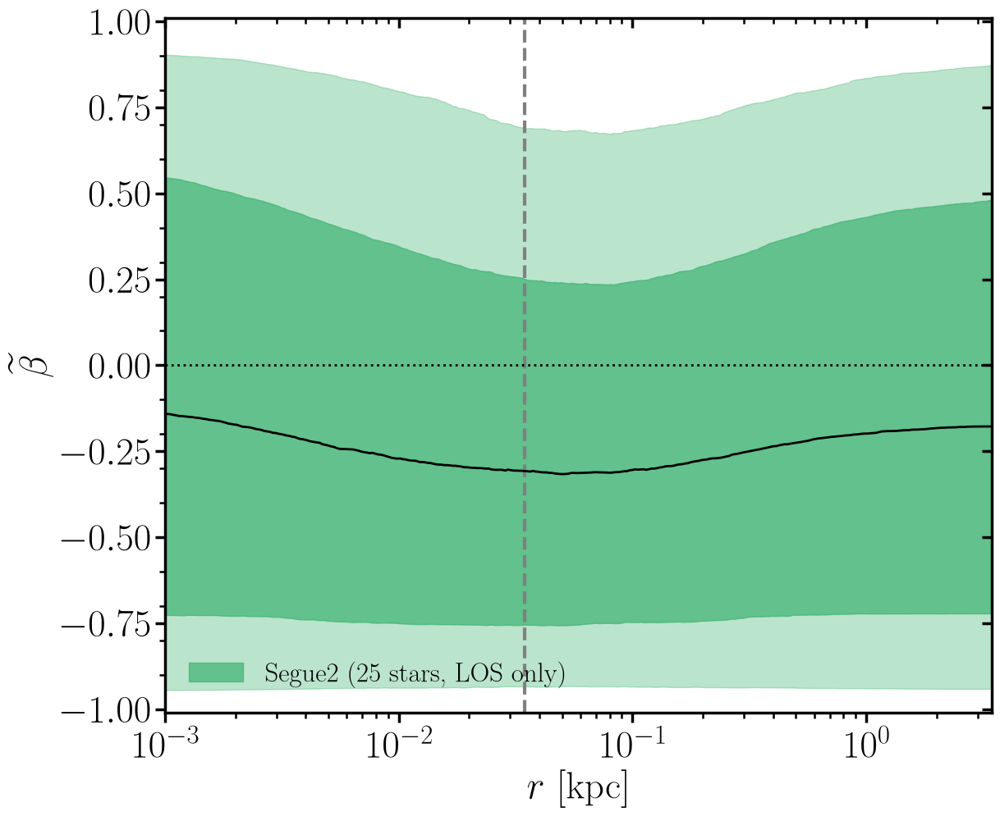

betat(R_half) = -0.31 -0.45 +0.56


In [23]:
upacs = np.zeros((len(s1flat), len(Ra)))
for k in range(len(s1flat)):
    theta = np.copy(s1flat[k])
    theta[0] = 2.0*theta[0]/(1 + theta[0])       # symmetrised -> ordinary beta
    theta[1] = 2.0*theta[1]/(1 + theta[1])
    for i in logthis:
        theta[i] = 10.0**theta[i]
    be = beta(Ra, theta[:4])
    upacs[k, :] = be / (2 - be)

b = band(upacs)
fig, ax = plt.subplots(figsize=(13, 11))
ax.fill_between(Ra, b[0], b[4], color=col, alpha=0.35, zorder=-1)
ax.fill_between(Ra, b[1], b[3], color=col, alpha=al, label=leg, zorder=-1)
ax.plot(Ra, b[2], color='k', lw=2.0)
ax.axhline(0.0, ls=':', color='k', lw=2.0)       # isotropic
ax.set_xlabel(r'$r$ [kpc]', fontsize=fsl)
ax.set_ylabel(r'$\widetilde{\beta}$', fontsize=fsl)
pretty_ax(ax, -1.01, 1.01)
ax.set_yticks(np.arange(-1.0, 1.01, 0.1), minor=True)
ax.legend(frameon=False, fontsize=fsl*0.7, loc='lower left')
plt.show()

q = np.percentile(upacs[:, np.argmin(np.abs(Ra - Rhalf))], [16, 50, 84])
print('betat(R_half) = %.2f -%.2f +%.2f' % (q[1], q[1]-q[0], q[2]-q[1]))

## To compare our simulations to observations using gravsphere - we aim to compare distributions of:
## $v_{los}(r)$, $\Sigma (r)$ and $\beta (r)$

In [24]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"

import sys
import pickle
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, "/gpfs/home/jd925/Adding_stellar_masses")
import jax
jax.config.update("jax_enable_x64", True)
import sys

sys.path.append("/gpfs/home/jd925/Adding_stellar_masses")
import jaxsp as jsp

In [25]:
m22 = 1000
r0 = 0.01
Lout = 0.5
rcut = None

WORKDIR = "/gpfs/home/jd925/Adding_stellar_masses/Checkpoints/SegII"

m22_str = f"{m22:g}"
r0_str = f"{r0:g}"
Lout_str = f"{Lout:g}"

if rcut is None:
    Ckpt_dir = os.path.join(WORKDIR, f"checkpoints_m22_{m22_str}_r0_{r0_str}_Lout_{Lout_str}")
else:
    Ckpt_dir = os.path.join(WORKDIR, f"checkpoints_rcut{rcut}_m22_{m22_str}_r0_{r0_str}_Lout_{Lout_str}")


u = jsp.set_schroedinger_units(m22)

to_Kpc = float(u.to_Kpc)
to_kms = float(u.to_kms)
to_Gyr = float(u.to_Gyr)

print(f"m22={m22}, r0={r0}, Lout={Lout} (checkpoints: {Ckpt_dir})")

# Load final checkpoint
ckpt_path = os.path.join(Ckpt_dir, "checkpoint_final.pkl")

print(f"\nLoading {ckpt_path}")

with open(ckpt_path, "rb") as f:
    state = pickle.load(f)

n_steps = state["no_time_steps"]
n_ramp  = state.get("n_ramp_steps", 0)
dt_Gyr  = (state["sim_time"] / n_steps) * to_Gyr
#dt_Gyr  = (state["sim_t"] / n_steps) * to_Gyr
print(f"Steps: {n_steps}, ramp steps: {n_ramp}, dt = {dt_Gyr:.5f} Gyr")

particles = state["particle_states"]

r_all  = np.array([p["r_values"] for p in particles])                              # (N_part, N_steps+1)
v_cart = np.array([[np.asarray(v) for v in p["velocities_cart"]] for p in particles])  # (N_part, N_steps+1, 3)
v_sph = np.array([[np.asarray(v) for v in p["velocities"]] for p in particles])      # (N_part, N_steps+1, 3)
r_pos = np.array([p["positions_xyz"] for p in particles])                              # (N_part, N_steps+1, 3)

N_part, N_t = r_all.shape
print(f"Particles: {N_part}, time points: {N_t}")


m22=1000, r0=0.01, Lout=0.5 (checkpoints: /gpfs/home/jd925/Adding_stellar_masses/Checkpoints/SegII/checkpoints_m22_1000_r0_0.01_Lout_0.5)

Loading /gpfs/home/jd925/Adding_stellar_masses/Checkpoints/SegII/checkpoints_m22_1000_r0_0.01_Lout_0.5/checkpoint_final.pkl


FileNotFoundError: [Errno 2] No such file or directory: '/gpfs/home/jd925/Adding_stellar_masses/Checkpoints/SegII/checkpoints_m22_1000_r0_0.01_Lout_0.5/checkpoint_final.pkl'

## $v_{los}(r)$

In [ ]:
# Pick arbitrary direction to be +ve z in cartesian coordinates

direction = np.array([0.0, 0.0, 1.0])

v_los = np.einsum("ijk,k->ij", v_cart, direction)  # (N_part, N_steps+1)

sim_v_los = v_los[:, -1] * to_kms  # (N_part,)

r_los = np.einsum("ijk,k->ij", r_pos, direction)  # (N_part, N_steps+1)

sim_r_proj = np.linalg.norm(r_pos[:, -1, :] - np.outer(r_los[:, -1], direction), axis=1) * to_Kpc


R_proj range = 0.0056 - 0.0983 kpc   (R_half = 0.0346 kpc)


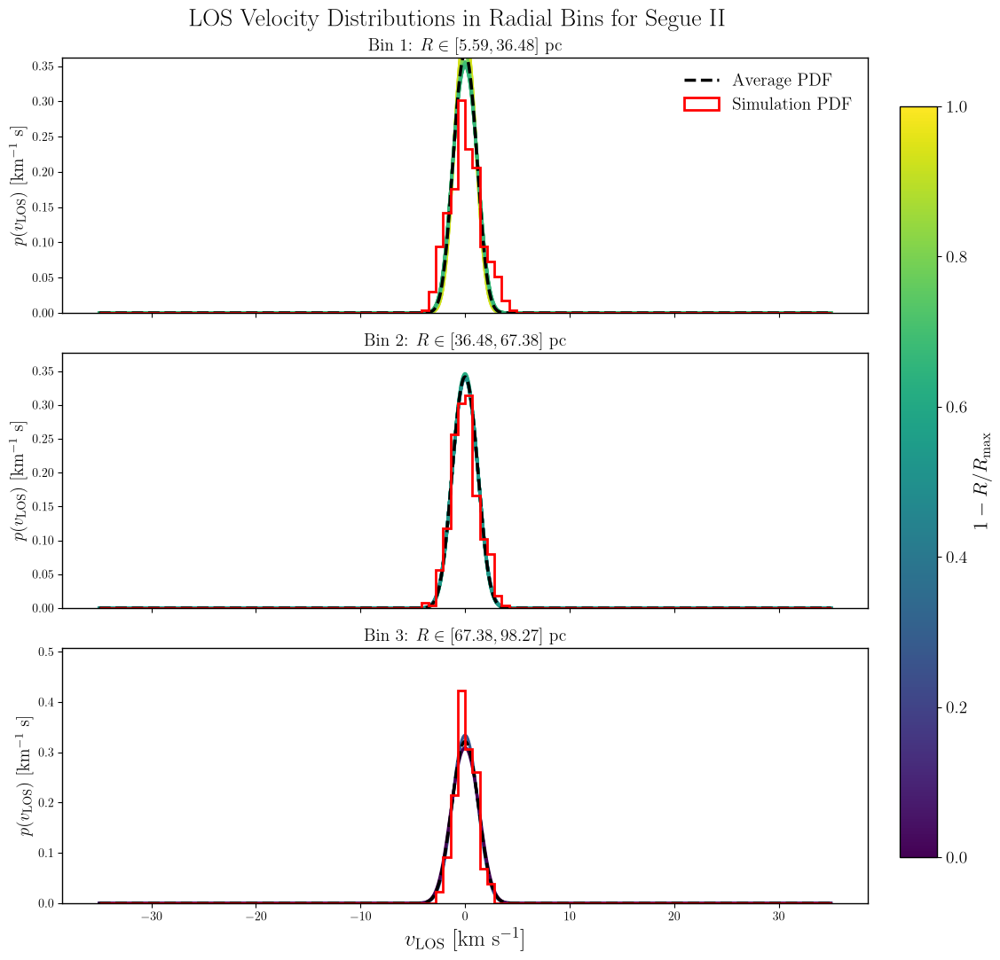

In [ ]:

n_bins = 3

rLOS = star_data[:, 0]

print('R_proj range = %.4f - %.4f kpc   (R_half = %.4f kpc)' % (rLOS.min(), rLOS.max(), Rhalf))

bin_edges = np.linspace(rLOS.min(), rLOS.max(), n_bins + 1)

fig, ax = plt.subplots(n_bins, 1, sharex=True, figsize=(13, 11))

for i in range(n_bins):
    mask = (rLOS >= bin_edges[i]) & (rLOS <= bin_edges[i + 1])
    bin_rLOS = rLOS[mask]
    bin_vLOS = star_data[mask, 1]
    bin_vLOS_err = star_data[mask, 2]

    bin_vLOS_err = np.zeros_like(star_data[mask,2])
    
    sig_at_bin = sig_at[mask]
    kur_at_bin = kur_at[mask]

    sim_mask = (sim_r_proj >= bin_edges[i]) & (sim_r_proj <= bin_edges[i + 1])
    sim_bin_v_los = sim_v_los[sim_mask]

    vv = np.linspace(-35.0, 35.0, 1000)

    max_hist = 0.0

    for j, (R, s, k) in enumerate(zip(bin_rLOS, sig_at_bin, kur_at_bin)):
        err = bin_vLOS_err[j]

        ax[i].plot(vv, fvel(vv, s, k, err), color=plt.cm.viridis(1 - R/R_max), lw=2.5,
                   ls='-')

    if len(bin_vLOS) > 0:

        average_pdf = np.mean([fvel(vv, s, k, err) for s, k, err in zip(sig_at_bin, kur_at_bin, bin_vLOS_err)], axis=0)
        
        ax[i].plot(vv, average_pdf, color='k', lw=2.5, ls='--', label='Average PDF')

        # for j in range(len(bin_vLOS)):

        #     ax[i].vlines(x = bin_vLOS[j], ymax = average_pdf[np.argmin(abs(vv - bin_vLOS[j]))], ymin = 0, color=plt.cm.viridis(1 - R/R_max), lw=2.5, ls='--', alpha = 0.4)

        y, x, _ = ax[i].hist(sim_bin_v_los, bins=100, range=(-35, 35), density=True, histtype='step', color='red', lw=2, label='Simulation PDF')


    # idx = np.clip(np.searchsorted(x, sim_bin_v_los, side='right') - 1, 0, len(y) - 1)
    # ax[i].vlines(sim_bin_v_los, 0, y[idx], color='red', ls='--', alpha=0.1)



    ax[i].set_ylabel(r'$p(v_{\rm LOS})$ [km$^{-1}$ s]', fontsize=14)
    ax[i].set_title(r'Bin %d: $R \in [%.2f, %.2f]$ pc' % (i + 1, bin_edges[i]*1000, bin_edges[i + 1]*1000), fontsize=14)
    if i == 0:
        ax[i].legend(frameon=False, fontsize=14)

    max_hist = np.max(y)
    ax[i].set_ylim(0, max_hist * 1.2)


ax[-1].set_xlabel(r'$v_{\rm LOS}$ [km s$^{-1}$]', fontsize=18)
fig.suptitle('LOS Velocity Distributions in Radial Bins for Segue II', fontsize=20, x=0.4)
cbar = fig.colorbar = plt.colorbar(plt.cm.ScalarMappable(cmap='viridis'),
                          ax=ax, orientation='vertical', pad = -0.45)

cbar.ax.tick_params(labelsize=14) 
cbar.set_label(r'$1 - R/R_{\max}$', size=16)

plt.tight_layout()
plt.show()


## $\Sigma(R)$

In [ ]:
n_bins = 5
r_bins = np.logspace(np.log10(rLOS.min()), np.log10(rLOS.max()), n_bins + 1)

masks = np.array([np.sum((sim_r_proj >= r_bins[i]) & (sim_r_proj <= r_bins[i+1])) for i in range(n_bins)])

keep = masks > 0                                  
sim_cen_d = (0.5*(r_bins[:-1] + r_bins[1:]))[keep]
sim_Sig_d = (masks/(np.pi*(r_bins[1:]**2 - r_bins[:-1]**2)))[keep] * (N_stars / N_part)
sim_f_pos_d = sim_cen_d*sim_Sig_d / np.trapezoid(sim_cen_d*sim_Sig_d, sim_cen_d)

print(sim_Sig_d)

[2724.58123448 2333.91483097 2021.62876354 1296.25508067  363.60008611]


200 / 200 draws kept


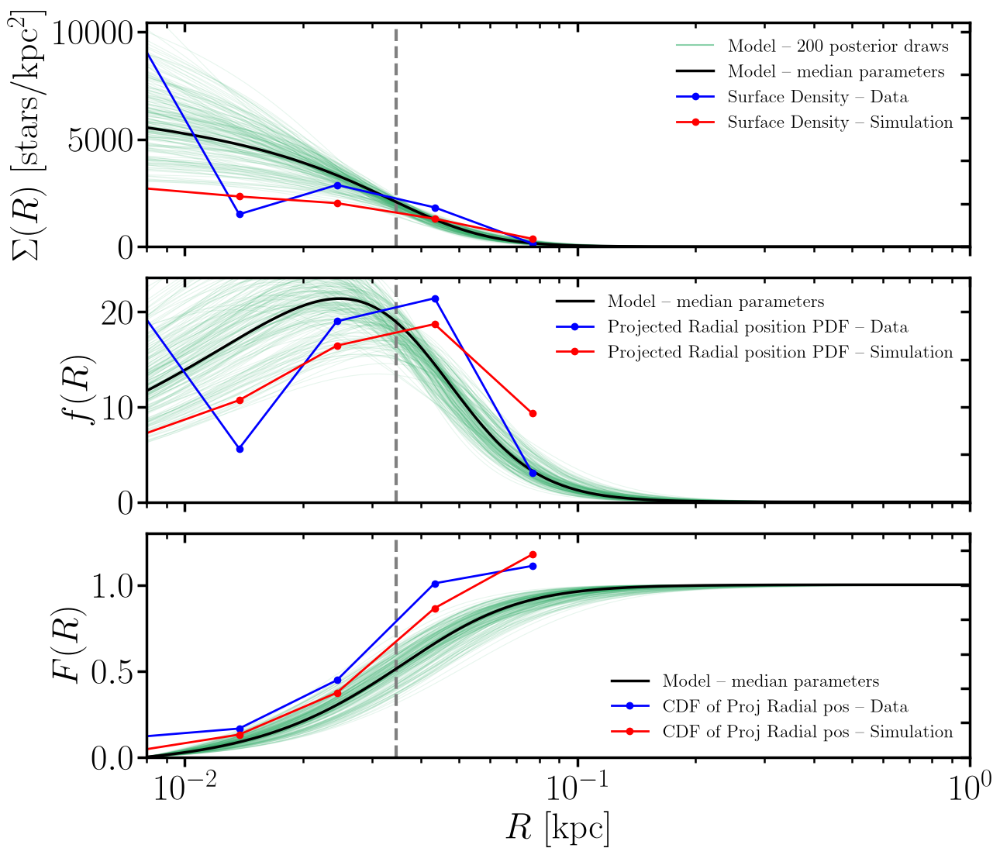

Sigma(R_half) = 1.97e+03 -200 +161  [stars/kpc^2]


In [ ]:

n_draw = 200
rng_draw = np.random.default_rng(42)
idx_draw = rng_draw.choice(len(s1flat), size=min(n_draw, len(s1flat)), replace=False)

Sigma_draws = np.zeros((len(idx_draw), len(Ra)))
for j, k in enumerate(idx_draw):
    rp_k = 10.0**s1flat[k, i_nu]
    alp_k, bet_k, gam_k = s1flat[k, i_nu+1], s1flat[k, i_nu+2], s1flat[k, i_nu+3]
    # same normalisation convention as the median model: total = N_stars
    rho_k = N_stars / abg_normmass(rp_k, alp_k, bet_k, gam_k)
    Sigma_draws[j, :] = Sigma_abg(Ra, rho_k, rp_k, alp_k, bet_k, gam_k)

good = np.all(np.isfinite(Sigma_draws), axis=1) & (Sigma_draws > 0).all(axis=1)
Sigma_draws = Sigma_draws[good]
print('%d / %d draws kept' % (good.sum(), len(good)))

f_pos_draws = Ra*Sigma_draws / np.trapezoid(Ra*Sigma_draws, Ra, axis=1)[:, None]
cdf_draws = np.cumsum(f_pos_draws*np.gradient(Ra), axis=1)


#--- binned data (recomputed here so the cell stands alone) -----------------------------------
rLOS = star_data[:, 0]


cnt = np.array([np.sum((rLOS >= r_bins[i]) & (rLOS <= r_bins[i+1])) for i in range(n_bins)])
keep = cnt > 0                                   # empty bins are dropped, as in the cell above
cen_d = (0.5*(r_bins[:-1] + r_bins[1:]))[keep]
Sig_d = (cnt/(np.pi*(r_bins[1:]**2 - r_bins[:-1]**2)))[keep]
f_pos_d = cen_d*Sig_d / np.trapezoid(cen_d*Sig_d, cen_d)


#--- plot -------------------------------------------------------------------------------------
dl = dict(color=col, lw=0.8, alpha=0.12, zorder=-1)     # thin per-draw lines

fig, ax = plt.subplots(3, 1, figsize=(13, 11), sharex=True)

ax[0].plot(Ra, Sigma_draws.T, **dl)
ax[0].plot([], [], color=col, lw=1.5, alpha=0.6,
           label=r'Model -- %d posterior draws' % len(Sigma_draws))
ax[0].plot(Ra, Sigma_model, color='k', lw=2.5, label='Model -- median parameters')
ax[0].plot(cen_d, Sig_d, 'o-', color='blue', lw=2.0, label='Surface Density -- Data')
ax[0].plot(sim_cen_d, sim_Sig_d, 'o-', color='red', lw=2.0, label='Surface Density -- Simulation')
ax[0].set_ylabel(r'$\Sigma(R)$ [stars/kpc$^2$]', fontsize=fsl)
pretty_ax(ax[0], 0.0, max(np.max(Sig_d*1.1), np.max(sim_Sig_d*1.1)), xlo = 8*10**(-3), xhi = 1)
ax[0].legend(frameon=False, fontsize=fsl*0.5, loc='upper right')

ax[1].plot(Ra, f_pos_draws.T, **dl)
ax[1].plot(Ra, f_pos_model, color='k', lw=2.5, label='Model -- median parameters')
ax[1].plot(cen_d, f_pos_d, 'o-', color='blue', lw=2.0, label='Projected Radial position PDF -- Data')
ax[1].plot(sim_cen_d, sim_f_pos_d, 'o-', color='red', lw=2.0, label='Projected Radial position PDF -- Simulation')
ax[1].set_ylabel(r'$f(R)$', fontsize=fsl)
pretty_ax(ax[1], ylo = 0.0, yhi = max(np.max(f_pos_d*1.1), np.max(sim_f_pos_d*1.1)), xlo = 8*10**(-3), xhi = 1)
ax[1].legend(frameon=False, fontsize=fsl*0.5, loc='upper right')

ax[2].plot(Ra, cdf_draws.T, **dl)
ax[2].plot(Ra, np.cumsum(f_pos_model*np.gradient(Ra)), color='k', lw=2.5, label='Model -- median parameters')
ax[2].plot(cen_d, np.cumsum(f_pos_d*np.gradient(cen_d)), 'o-', c='blue', lw=2.0,
           label='CDF of Proj Radial pos -- Data')
ax[2].plot(sim_cen_d, np.cumsum(sim_f_pos_d*np.gradient(sim_cen_d)), 'o-', c='red', lw=2.0,
           label='CDF of Proj Radial pos -- Simulation')
pretty_ax(ax[2], ylo = 0.0, yhi = 1.3, xlo = 8*10**(-3), xhi = 1)
ax[2].set_xlabel(r'$R$ [kpc]', fontsize=fsl)
ax[2].set_ylabel(r'$F(R)$', fontsize=fsl)
ax[2].legend(frameon=False, fontsize=fsl*0.5, loc='lower right')

plt.tight_layout()
plt.show()

#--- 68 / 95 per cent envelopes of the drawn Sigma(R), for reference ---------------------------
bS = band(Sigma_draws)
qh = np.percentile(Sigma_draws[:, np.argmin(np.abs(Ra - Rhalf))], [16, 50, 84])
print('Sigma(R_half) = %.3g -%.3g +%.3g  [stars/kpc^2]' % (qh[1], qh[1]-qh[0], qh[2]-qh[1]))


## $\beta(r)$

In [ ]:
# Simulation Beta

beta_sim_plot = []

n_bins = 8

for i in range(2):

    if i == 0:
        time = 0
    else:
        time = -1

    r_bins = np.logspace(np.log10(r_all[:, time].min()), np.log10(r_all[:, time].max()), n_bins + 1)

    bin_centers = 0.5 * (r_bins[:-1] + r_bins[1:])

    masks = [(r_all[:, time] >= r_bins[i]) & (r_all[:, time] <= r_bins[i+1]) for i in range(n_bins)]

    sigma_t = np.zeros(n_bins)
    sigma_r = np.zeros(n_bins)


    def Cartesian_to_sph_vel_np(x, y, z, vx, vy, vz):
        r = np.sqrt(x*x + y*y + z*z)
        rho_xy = np.sqrt(x*x + y*y)
        vr = (x*vx + y*vy + z*vz) / r
        vtheta = (z*(x*vx + y*vy) - (x**2 + y**2) * vz) / (r * rho_xy)
        vphi = (x*vy - y*vx) / rho_xy
        return vr, vtheta, vphi

    vr, vtheta, vphi = Cartesian_to_sph_vel_np(r_pos[:, time, 0], r_pos[:, time, 1], r_pos[:, time, 2],
                                            v_cart[:, time, 0], v_cart[:, time, 1], v_cart[:, time, 2])


    for i in range(n_bins):
        mask = masks[i]
        if np.sum(mask) > 20:
            sigma_theta = np.sqrt(np.mean(vtheta[mask]**2) - np.mean(vtheta[mask])**2) * to_kms
            sigma_phi = np.sqrt(np.mean(vphi[mask]**2) - np.mean(vphi[mask])**2) * to_kms
            sigma_t[i] = np.sqrt(sigma_theta**2 + sigma_phi**2)
            sigma_r[i] = np.sqrt(np.mean(vr[mask]**2) - np.mean(vr[mask])**2) * to_kms
        else:
            sigma_t[i] = np.nan
            sigma_r[i] = np.nan


    beta_sim = 1 - (sigma_t**2) / (2 * sigma_r**2)

    bin_centers = bin_centers[~np.isnan(beta_sim)]
    beta_sim = beta_sim[~np.isnan(beta_sim)]

    #beta_sim = beta_sim / (2 - beta_sim)

    beta_sim_plot.append((bin_centers, beta_sim))




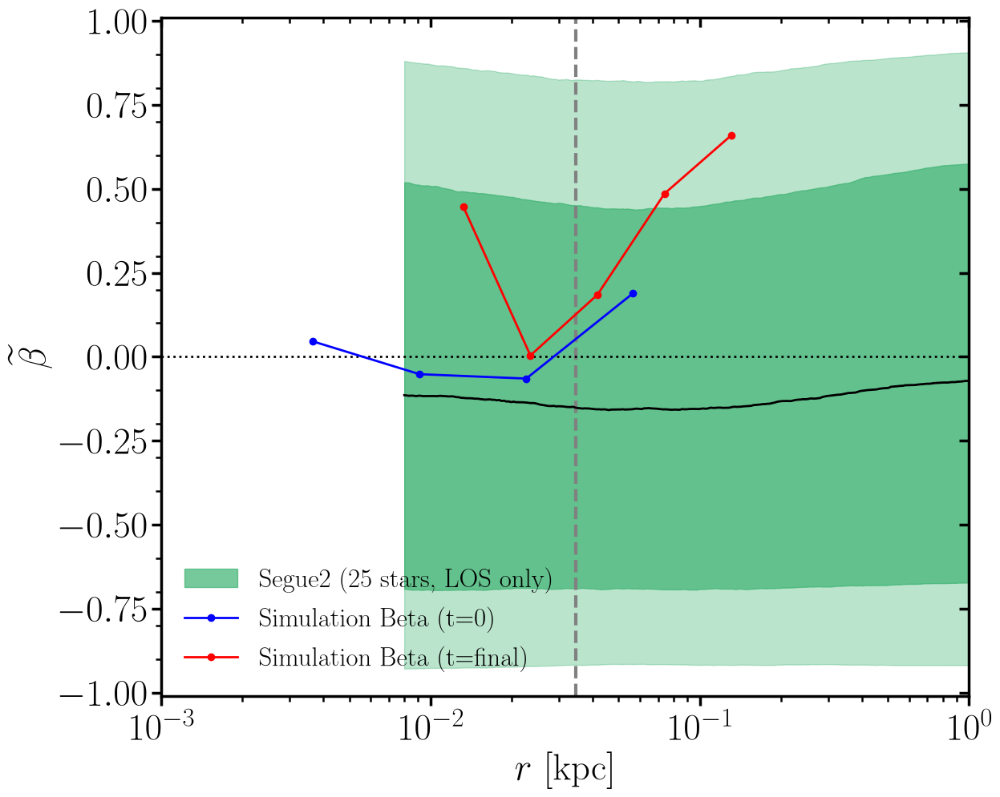

betat(R_half) = -0.15 -0.54 +0.60


In [ ]:
upacs = np.zeros((len(s1flat), len(Ra)))
for k in range(len(s1flat)):
    theta = np.copy(s1flat[k])
    theta[0] = 2.0*theta[0]/(1 + theta[0])       # symmetrised -> ordinary beta
    theta[1] = 2.0*theta[1]/(1 + theta[1])
    for i in logthis:
        theta[i] = 10.0**theta[i]
    be = beta(Ra, theta[:4])
    upacs[k, :] = be / (2 - be)

b = band(upacs)
fig, ax = plt.subplots(figsize=(13, 11))
ax.fill_between(Ra, b[0], b[4], color=col, alpha=0.35, zorder=-1)
ax.fill_between(Ra, b[1], b[3], color=col, alpha=al, label=leg, zorder=-1)
ax.plot(Ra, b[2], color='k', lw=2.0)
ax.axhline(0.0, ls=':', color='k', lw=2.0)       # isotropic

for i in range(2):
    bin_centers, beta_sim = beta_sim_plot[i]
    l = 'Simulation Beta (t=0)' if i == 0 else 'Simulation Beta (t=final)'
    color = 'blue' if i == 0 else 'red'
    ax.plot(bin_centers * to_Kpc, beta_sim, 'o-', color=color, lw=2.0, label=l)

ax.set_xlabel(r'$r$ [kpc]', fontsize=fsl)
ax.set_ylabel(r'$\widetilde{\beta}$', fontsize=fsl)
pretty_ax(ax, ylo = -1.01, yhi = 1.01, xlo = 1e-3, xhi = 1)
ax.set_yticks(np.arange(-1.0, 1.01, 0.1), minor=True)
ax.legend(frameon=False, fontsize=fsl*0.7, loc='lower left')
plt.show()

q = np.percentile(upacs[:, np.argmin(np.abs(Ra - Rhalf))], [16, 50, 84])
print('betat(R_half) = %.2f -%.2f +%.2f' % (q[1], q[1]-q[0], q[2]-q[1]))

## cNFWt (coreNFWtides) parameter posteriors

The DM halo block of $\Theta$ is columns `i_dm = 2*n_betpars + nu_components` to `i_dm+5`:
$\log M_{200}$, $c_{200}$, $\log r_c$, $n$, $\log r_t$, $\delta$.

Three views below: (1) the $6\times6$ corner of just those columns, drawn on the **prior box** so a
marginal that fills its panel is prior-limited; (2) the 1D marginals with the flat prior overlaid and
the KL divergence posterior-vs-prior, which says how many nats the 25 stars actually bought;
(3) the derived halo quantities ($r_{200}$, $r_s$, $r_c/R_{1/2}$, $r_t/R_{\rm max}$, $M(<R_{1/2})$),
which are what the data constrain even when the sampled parameters are not.

Read these with the warning in `initialise_Seg2.py` in mind: Segue 2's dispersion is an upper limit,
so a tight-looking $M_{200}$ is a prior statement unless the KL number says otherwise.

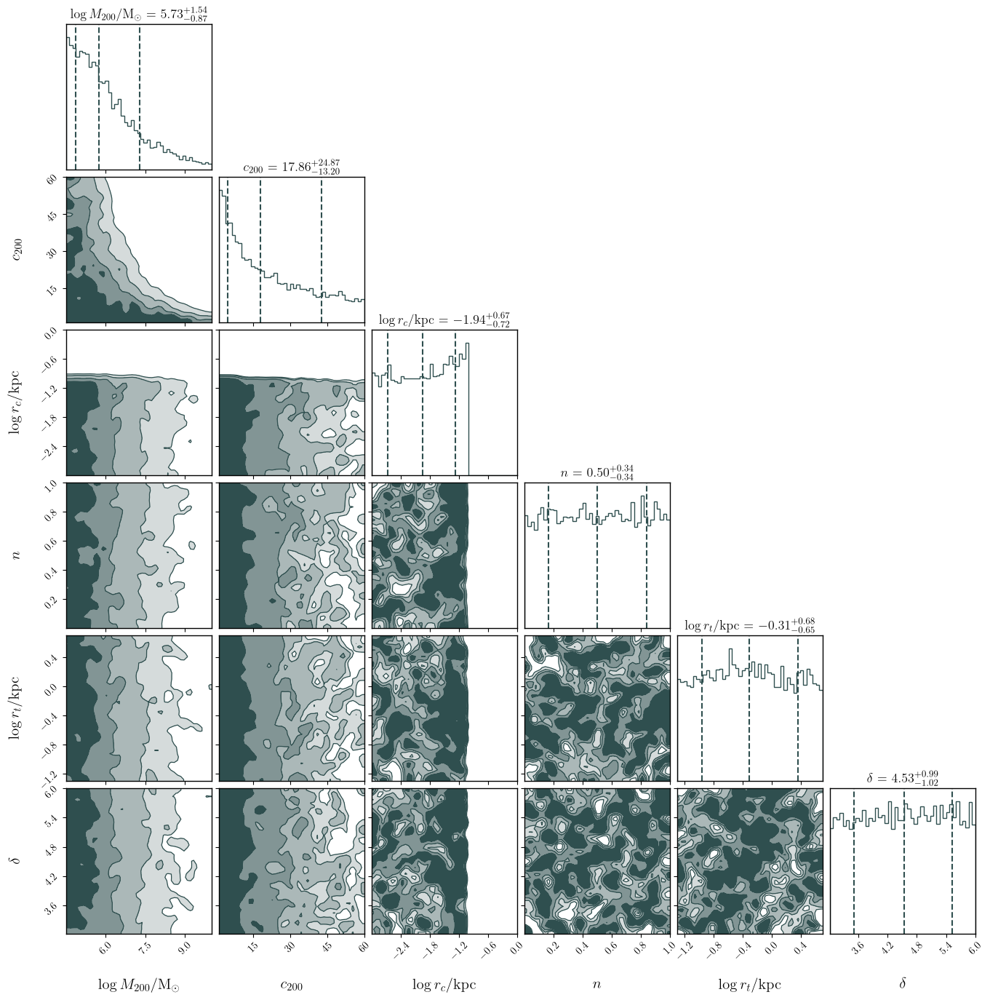

param                16%       50%       84%   prior              f_low  f_high
logM200            4.860     5.731     7.273   [  4.50,  10.00]    0.24    0.01
c200               4.662    17.863    42.733   [  1.00,  60.00]    0.24    0.05
log rc            -2.664    -1.943    -1.278   [ -3.00,   0.00]    0.14    0.00
n                  0.164     0.501     0.842   [  0.00,   1.00]    0.10    0.10
log rt            -0.963    -0.313     0.366   [ -1.30,   0.70]    0.09    0.10
delta              3.508     4.533     5.522   [  3.01,   6.00]    0.10    0.10

f_low/f_high = posterior fraction inside the outer 10% of the prior range
(a flat prior gives 0.10 each; >~0.3 means the edge, not the data, is setting the limit)


In [44]:
#--- cNFWt only: 6x6 corner on the prior box --------------------------------------------------
import corner

i_dm   = 2*n_betpars + nu_components          # first coreNFWtides column (12 for ndims = 18)
dm_idx = np.arange(i_dm, i_dm + 6)
dm_labs = [r'$\log M_{200}$/M$_{\odot}$', r'$c_{200}$', r'$\log r_c$/kpc',
           r'$n$', r'$\log r_t$/kpc', r'$\delta$']
dm_samp = s1flat[:, dm_idx]
dm_rng  = [(minarr[i], maxarr[i]) for i in dm_idx]

levs_dm = (1 - np.exp(-(1.0)**2/2), 1 - np.exp(-(1.5)**2/2),
           1 - np.exp(-(2.0)**2/2), 1 - np.exp(-(2.5)**2/2))

fig = corner.corner(dm_samp, labels=dm_labs, range=dm_rng,
                    quantiles=(0.16, 0.5, 0.84), show_titles=True, title_fmt='.2f',
                    label_kwargs=dict(fontsize=15), title_kwargs=dict(fontsize=13),
                    bins=45, smooth=1.1, fill_contours=True, color='darkslategray',
                    plot_datapoints=False, plot_density=False,
                    contour_kwargs={'linewidths': 0.9}, levels=levs_dm, use_math_text=True)

plt.savefig(str(diro + 'Plots/corner_cnfwt.pdf'), bbox_inches='tight')
plt.show()

#--- how much of each marginal is jammed against its prior edge? ------------------------------
print('%-14s %9s %9s %9s   %-16s %7s %7s' %
      ('param', '16%', '50%', '84%', 'prior', 'f_low', 'f_high'))
for j, i in enumerate(dm_idx):
    lo, hi = minarr[i], maxarr[i]
    q = np.percentile(s1flat[:, i], [16, 50, 84])
    edge = 0.1*(hi - lo)                                   # outer 10% of the prior range
    f_lo = np.mean(s1flat[:, i] < lo + edge)
    f_hi = np.mean(s1flat[:, i] > hi - edge)
    flag = ''
    if f_lo > 0.3: flag = '  <- piled on lower edge'
    if f_hi > 0.3: flag = '  <- piled on upper edge'
    print('%-14s %9.3f %9.3f %9.3f   [%6.2f, %6.2f] %7.2f %7.2f%s'
          % (['logM200', 'c200', 'log rc', 'n', 'log rt', 'delta'][j],
             q[0], q[1], q[2], lo, hi, f_lo, f_hi, flag))
print('\nf_low/f_high = posterior fraction inside the outer 10% of the prior range')
print('(a flat prior gives 0.10 each; >~0.3 means the edge, not the data, is setting the limit)')

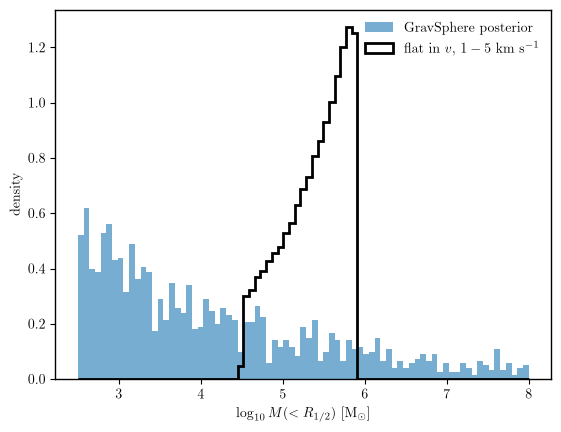

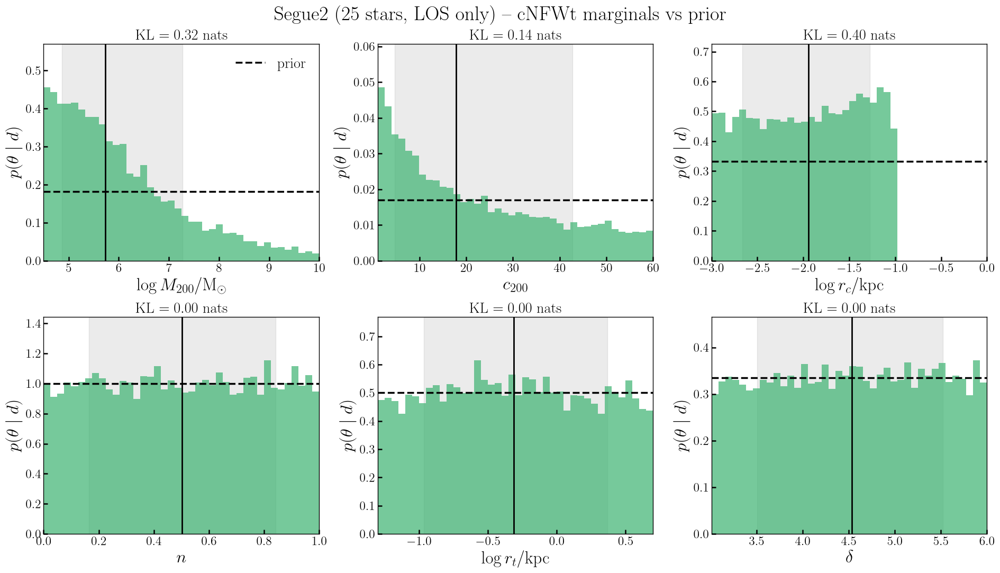

In [ ]:
#--- cNFWt: 1D marginals against the flat prior, with the information gain ---------------------
# KL(posterior || prior) in nats, computed on the same histogram that is drawn. 0 nats = the
# marginal IS the prior (the 25 Segue 2 velocities said nothing about that parameter);
# ~1 nat = the posterior occupies roughly 1/e of the prior range.


nbins_m = 40
fig, axs = plt.subplots(2, 3, figsize=(19, 11))

for ax, i, lab in zip(axs.ravel(), dm_idx, dm_labs):
    lo, hi = minarr[i], maxarr[i]
    p, edges = np.histogram(s1flat[:, i], bins=nbins_m, range=(lo, hi), density=True)
    cen = 0.5*(edges[:-1] + edges[1:])
    dx = edges[1] - edges[0]
    prior = 1.0/(hi - lo)
    kl = np.sum(np.where(p > 0, p*np.log(np.where(p > 0, p, 1.0)/prior), 0.0))*dx

    q = np.percentile(s1flat[:, i], [16, 50, 84])
    ax.bar(cen, p, width=dx, color=col, alpha=al, edgecolor='none')
    ax.axhline(prior, ls='--', lw=2.5, color='k', label='prior')
    ax.axvspan(q[0], q[2], color='k', alpha=0.08, zorder=0)
    ax.axvline(q[1], color='k', lw=2.0, zorder=3)
    ax.set_xlim(lo, hi)
    ax.set_ylim(0.0, max(p.max(), prior)*1.25)
    ax.set_xlabel(lab, fontsize=fsl*0.7)
    ax.set_ylabel(r'$p(\theta \mid d)$', fontsize=fsl*0.7)
    ax.set_title(r'KL $= %.2f$ nats' % kl, fontsize=fsl*0.6)
    ax.tick_params(labelsize=fst*0.5)
    ax.tick_params('both', length=6, width=1.8, which='major', direction='in')

axs.ravel()[0].legend(frameon=False, fontsize=fsl*0.6, loc='upper right')
fig.suptitle(leg + r' -- cNFWt marginals vs prior', fontsize=fsl*0.8)
plt.tight_layout()
plt.savefig(str(diro + 'Plots/marginals_cnfwt.pdf'), bbox_inches='tight')
plt.show()

In [46]:
import jax.numpy as jnp
import jax
import sys
sys.path.append('/gpfs/home/jd925/Adding_stellar_masses/simple_sim')
import Sharding_manager as sm

sys.path.append('/gpfs/home/jd925/Adding_stellar_masses')
import jaxsp as jsp


m22 = 1000
u = jsp.set_schroedinger_units(m22)
no_radius_bins = 1000
R_bin = no_radius_bins
r_min = 0.05
r_max_enclosing_frac = 0.99

gal_name = "SegII"

[CpuDevice(id=0)]


In [47]:
# Sample the posteriors 

n_draw = 1
rng_draw = np.random.default_rng(42)
idx_draw = rng_draw.choice(len(s1flat), size=min(n_draw, len(s1flat)), replace=False)

param_draws = np.zeros((len(idx_draw), len(dm_idx)))
for j, k in enumerate(idx_draw):
    for l, i in enumerate(dm_idx):
        param_draw = s1flat[k, i]

        param_draws[j, l] = param_draw

for draw in param_draws:

    cNFWtides_params = jnp.array([
    10**draw[0] * u.from_Msun,
    draw[1],
    draw[3],
    10**(draw[2]) * u.from_Kpc,
    10**(draw[4]) * u.from_Kpc,
    draw[5]
    ])

    u = jsp.set_schroedinger_units(m22)

    print("Initializing density parameters...")

    density_params = jsp.init_core_NFW_tides_params_from_sample(cNFWtides_params)

    N = 512
    rmin = 0.01 * u.from_pc
    rmax = jsp.enclosing_radius(0.999, density_params)

    print("Initializing potential parameters...")
    potential_params = jsp.init_potential_params(density_params, rmin, rmax, N)



    eval_library = jax.vmap(jax.vmap(jsp.eval_radial_eigenmode, in_axes=(None, 0)), in_axes=(0,None))

    N = 1024
    a = 1
    b = 10

    rmax = jsp.enclosing_radius(r_max_enclosing_frac, density_params)

    print("Initializing eigenstate library...")
    cpu = jax.devices('cpu')[0]
    with jax.default_device(cpu):
        eigenstate_lib = jsp.init_eigenstate_library(potential_params, rmin, rmax, a, b, N)
    print(f"  eigenstate_lib.J={eigenstate_lib.J}, J % {len(jax.devices())} devices = {eigenstate_lib.J % len(jax.devices())}")

    rmin = r_min * u.from_pc

    tol = 1e-7
    print("Initializing wavefunction parameters...")
    wavefunction_params = jsp.init_wavefunction_params(eigenstate_lib, density_params, rmin, rmax, tol, sharding_manager=sm)


    print("Creating wavefunctions...")
    r = jnp.logspace(jnp.log10(rmin), jnp.log10(rmax), R_bin)

    Nj = eigenstate_lib.J
    chunk = 256
    R_j_r_chunks = []
    for i in range(0, Nj, chunk):
        chunk_result = eval_library(r, jax.tree.map(lambda x: x[i:i+chunk], eigenstate_lib.radial_eigenmode_params))
        R_j_r_chunks.append(np.array(chunk_result))

    R_j_r = np.concatenate(R_j_r_chunks, axis=1)

    l          = np.array(eigenstate_lib.radial_eigenmode_params.l)
    E          = np.array(eigenstate_lib.radial_eigenmode_params.E)
    aj_2       = np.array(wavefunction_params.aj_2)
    total_mass = float(wavefunction_params.total_mass)


    rho_r = ((2 * l + 1)/ (4*np.pi) * abs(R_j_r)**2 * total_mass) @ aj_2

    plt.plot(r, rho_r, label = r'$\psi\psi^*$')

    rho_cnfwt = jsp.core_nfw_tides_rho(r, density_params)

    plt.plot(r, rho_cnfwt, label = 'cNFWt from params')


plt.xscale('log')
plt.yscale('log')
plt.xlabel('R[Kpc]')
plt.ylabel(r'$\rho(r)$')
plt.legend()

plt.show()

Initializing density parameters...
Initializing potential parameters...
Initializing eigenstate library...


KeyboardInterrupt: 

In [48]:
def sigma_los_model(Theta, R):
    """sigma_LOS(R) [km/s] at projected radii R [kpc] for one sample Theta
    (in the sampled space, same layout as resu.samples)."""
    theta = np.copy(Theta)
    for j in (0, 1, 4, 5):                       # symmetrised -> normal anisotropy
        theta[j] = 2.0*theta[j]/(1.0 + theta[j])
    for i in logthis:                            # un-log the log-sampled parameters
        theta[i] = 10**theta[i]

    surc = theta[2*n_betpars: 2*n_betpars+nu_components]
    if individual:
        surc = np.append(np.array([1.0]), surc)  # normalisation cancels in sigma
    rhobs = alpbetgamden(nu_rad, *surc)
    sobs  = alpbetgamsurf(nu_rad, *surc, bar_pnts)
    nu  = lambda r: np.interp(r, nu_rad, rhobs, right=1e-30)
    Sig = lambda r: np.interp(r, nu_rad, sobs,  right=1e-30)

    i0 = 2*n_betpars + nu_components
    Mpars = theta[i0:i0+6]
    if Mstar > 0.0:
        rho0, r0, alp, bet, gam = surc
        normmass = 12.566370614359172 * rho0 * ((1/r0)**alp)**((-3 + gam)/alp) * (1/r0)**(-gam) \
            * gamma((bet - gam)/alp + (-3 + gam)/alp) * gamma((3 - gam)/alp) \
            / (gamma((bet - gam)/alp) * alp)
        Mst = theta[i0+6]
        M = lambda r, p: corenfw_tides_mass(r, *p) + alpbetgammass(r, *surc) * Mst / normmass
    else:
        M = lambda r, p: corenfw_tides_mass(r, *p)

    _, los2, _, _ = sigp_k(R, R, nu, Sig, M, beta, betaf, Mpars,
                           theta[:4], theta[4:8], rmin, rmax)
    return np.sqrt(los2)/1e3


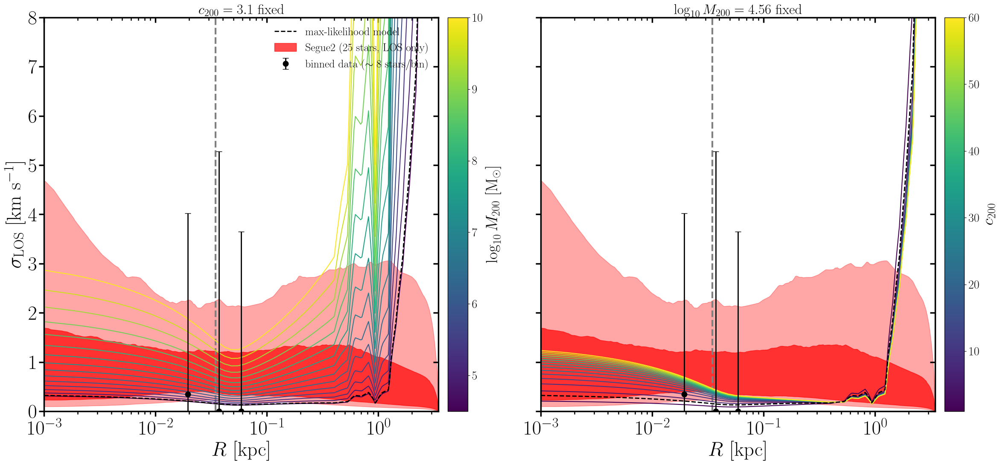

In [49]:
base = resu.samples[np.argmax(resu.logl)]        # max-likelihood sample as the fiducial
iM = 2*n_betpars + nu_components                 # index of logM200 (then c, log rc, n, log rt, delta)

# --- one-at-a-time sweeps across the prior; everything else held at `base` ---
nsweep = 15
sweeps = [
    (iM,   np.linspace(minarr[iM],   maxarr[iM],   nsweep), plt.cm.viridis,
     r'$\log_{10} M_{200}$ [M$_\odot$]',
     r'$c_{200} = %.1f$ fixed' % base[iM+1]),
    (iM+1, np.linspace(minarr[iM+1], maxarr[iM+1], nsweep), plt.cm.viridis,
     r'$c_{200}$',
     r'$\log_{10} M_{200} = %.2f$ fixed' % base[iM]),
]

b = np.loadtxt(str(diro + s1file + '_sl.txt'))

fig, axes = plt.subplots(1, 2, figsize=(24, 11), sharey=True)
for ax, (idx, vals, cmap, cblab, fixlab) in zip(axes, sweeps):
    norm = plt.Normalize(vals.min(), vals.max())
    for v in vals:
        th = np.copy(base); th[idx] = v
        ax.plot(Ra, sigma_los_model(th, Ra), color=cmap(norm(v)), lw=1.5, zorder=1)
    ax.plot(Ra, sigma_los_model(base, Ra), color='k', ls='--', lw=2.0, zorder=2,
            label='max-likelihood model')

    ax.fill_between(Ra, b[0], b[4], color='red', alpha=0.35, zorder=-1)
    ax.fill_between(Ra, b[1], b[3], color='red', alpha=al, label=leg, zorder=-1)
    ax.errorbar(Rb, sb, yerr=sberr, fmt='o', color='k', ms=9, capsize=5, lw=2.0, zorder=5,
                label=r'binned data ($\sim %d$ stars/bin)' % (len(Rs)//nbin))

    cb = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax, pad=0.02)
    cb.set_label(cblab, fontsize=fsl*0.8)
    cb.ax.tick_params(labelsize=fsl*0.6)

    ax.set_xlabel(r'$R$ [kpc]', fontsize=fsl)
    ax.set_title(fixlab, fontsize=fsl*0.7)
    pretty_ax(ax, 0.0, 8.0)

axes[0].set_ylabel(r'$\sigma_{\rm LOS}$ [km s$^{-1}$]', fontsize=fsl)
axes[0].legend(frameon=False, fontsize=fsl*0.55, loc='upper right')
plt.tight_layout()
plt.show()



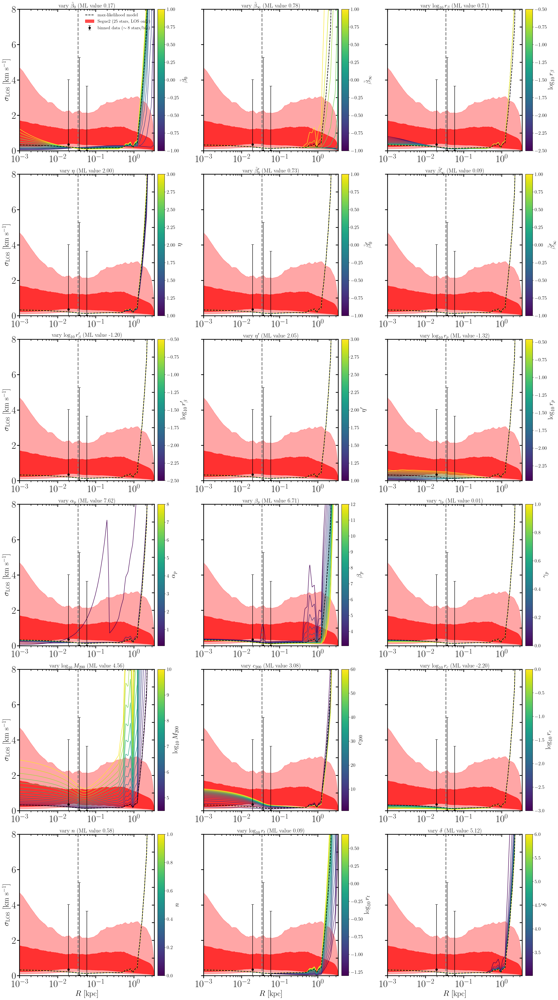

In [50]:
base = resu.samples[np.argmax(resu.logl)]        # max-likelihood sample as the fiducial
iM = 2*n_betpars + nu_components                 # index of logM200 (then c, log rc, n, log rt, delta)
#base[iM] = 6

tex = {0: r'$\tilde\beta_0$', 1: r'$\tilde\beta_\infty$', 2: r'$\log_{10} r_\beta$', 3: r'$\eta$',
       4: r"$\tilde\beta_0'$", 5: r"$\tilde\beta_\infty'$", 6: r"$\log_{10} r_\beta'$", 7: r"$\eta'$",
       8: r'$\log_{10} r_p$', 9: r'$\alpha_p$', 10: r'$\beta_p$', 11: r'$\gamma_p$',
       iM: r'$\log_{10} M_{200}$', iM+1: r'$c_{200}$', iM+2: r'$\log_{10} r_c$',
       iM+3: r'$n$', iM+4: r'$\log_{10} r_t$', iM+5: r'$\delta$',
       iM+6: r'$M_\star$ [M$_\odot$]'}          # only used if Mstar > 0 (ndims = 19)

sweep_idx = list(range(ndims))                   # every sampled parameter

nsweep = 15
cmap = plt.cm.viridis

b = np.loadtxt(str(diro + s1file + '_sl.txt'))
sig_base = sigma_los_model(base, Ra)

ncol = 3
nrow = int(np.ceil(len(sweep_idx)/ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(9*ncol, 8*nrow), sharey=True, squeeze=False)

for ax, idx in zip(axes.flat, sweep_idx):
    vals = np.linspace(minarr[idx], maxarr[idx], nsweep)   # evenly across the prior
    norm = plt.Normalize(vals.min(), vals.max())
    for v in vals:
        th = np.copy(base); th[idx] = v
        ax.plot(Ra, sigma_los_model(th, Ra), color=cmap(norm(v)), lw=1.5, zorder=1)
    ax.plot(Ra, sig_base, color='k', ls='--', lw=2.0, zorder=2, label='max-likelihood model')

    ax.fill_between(Ra, b[0], b[4], color='red', alpha=0.35, zorder=-1)
    ax.fill_between(Ra, b[1], b[3], color='red', alpha=al, label=leg, zorder=-1)
    ax.errorbar(Rb, sb, yerr=sberr, fmt='o', color='k', ms=7, capsize=4, lw=1.5, zorder=5,
                label=r'binned data ($\sim %d$ stars/bin)' % (len(Rs)//nbin))

    cb = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax, pad=0.02)
    cb.set_label(tex[idx], fontsize=fsl*0.7)
    cb.ax.tick_params(labelsize=fsl*0.5)

    pretty_ax(ax, 0.0, 8.0)
    ax.set_title(r'vary %s  (ML value %.2f)' % (tex[idx], base[idx]), fontsize=fsl*0.6)

for ax in axes.flat[len(sweep_idx):]:            # hide unused panels
    ax.set_visible(False)
for ax in axes[-1]:
    ax.set_xlabel(r'$R$ [kpc]', fontsize=fsl*0.8)
for ax in axes[:, 0]:
    ax.set_ylabel(r'$\sigma_{\rm LOS}$ [km s$^{-1}$]', fontsize=fsl*0.8)
axes[0, 0].legend(frameon=False, fontsize=fsl*0.45, loc='upper right')

plt.tight_layout()
plt.show()


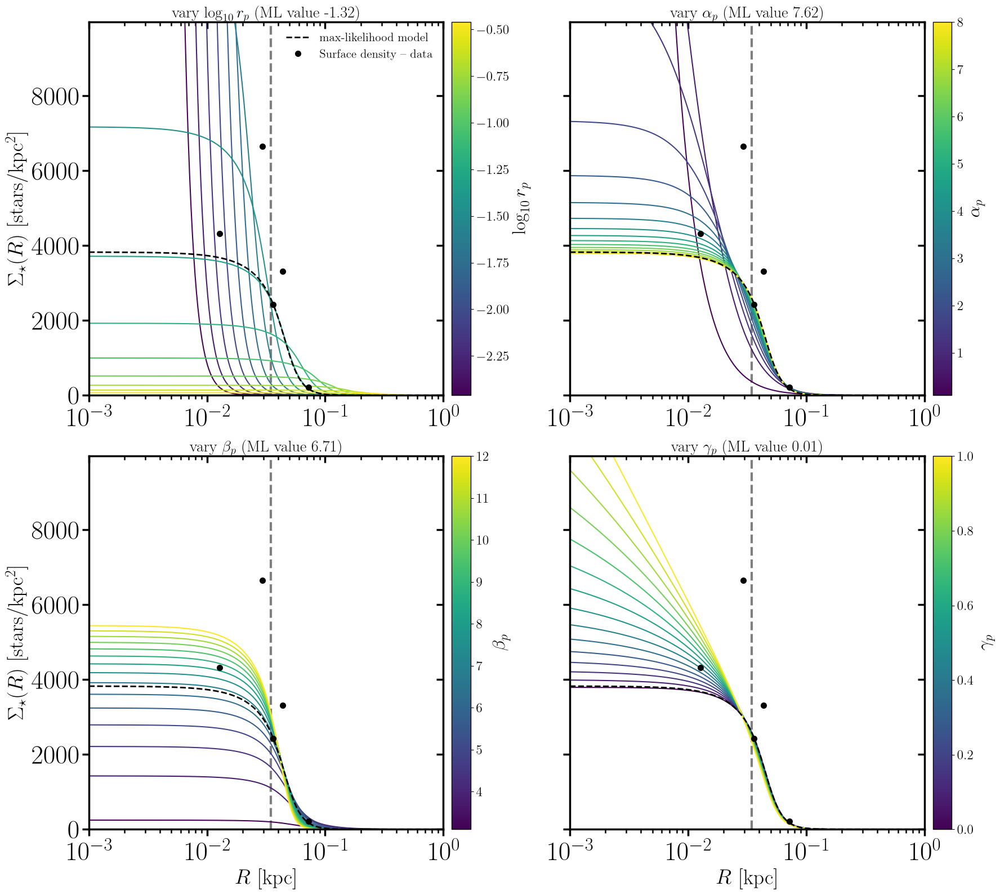

In [51]:
#--- Segue2: one-at-a-time parameter sweeps of Sigma_*(R) -------------------------------------
# Start from the max-likelihood sample and vary one parameter at a time evenly across its
# prior. Sigma_*(R) only depends on the light-profile parameters (i_nu ... i_nu+3), so
# every other panel is flat by construction.
from scipy.special import gamma as gammafn


star_data = np.loadtxt('/gpfs/home/jd925/GravSphere2/Data/Seg2/Seg2_Rproj_vlos_vloserr.txt')

base = resu.samples[np.argmax(resu.logl)]
iM = 2*n_betpars + nu_components
base[iM] = 6.0

tex = {0: r'$\tilde\beta_0$', 1: r'$\tilde\beta_\infty$', 2: r'$\log_{10} r_\beta$', 3: r'$\eta$',
       4: r"$\tilde\beta_0'$", 5: r"$\tilde\beta_\infty'$", 6: r"$\log_{10} r_\beta'$", 7: r"$\eta'$",
       8: r'$\log_{10} r_p$', 9: r'$\alpha_p$', 10: r'$\beta_p$', 11: r'$\gamma_p$',
       iM: r'$\log_{10} M_{200}$', iM+1: r'$c_{200}$', iM+2: r'$\log_{10} r_c$',
       iM+3: r'$n$', iM+4: r'$\log_{10} r_t$', iM+5: r'$\delta$',
       iM+6: r'$M_\star$ [M$_\odot$]'}

sweep_idx = list(range(i_nu, i_nu+4))                   # all parameters; use range(i_nu, i_nu+4) for the ones that matter
nsweep = 15
cmap = plt.cm.viridis


def Sigma_from_theta(Theta, R):
    """Sigma_*(R) [stars/kpc^2] for one sample Theta in the sampled space, normalised to N_stars."""
    rp = 10.0**Theta[i_nu]
    alp, bet, gam = Theta[i_nu+1], Theta[i_nu+2], Theta[i_nu+3]
    rho = N_stars / abg_normmass(rp, alp, bet, gam)
    return Sigma_abg(R, rho, rp, alp, bet, gam)

def Sigma_abg(R, rho0, r0, alp, bet, gam, npts=2000, zmax=200.0):
    R = np.atleast_1d(R)
    z = np.logspace(-6, np.log10(zmax), npts)[None, :]      # kpc
    rr = np.sqrt(R[:, None]**2 + z**2)
    return 2.0*np.trapezoid(alpbetgamden(rr, rho0, r0, alp, bet, gam), z, axis=1)


def abg_normmass(r0, alp, bet, gam, rho0=1.0):
    return (4*np.pi*rho0*r0**3 * gammafn((bet - 3)/alp) * gammafn((3 - gam)/alp)
            / (gammafn((bet - gam)/alp) * alp))

N_stars = len(rLOS)


#--- binned data (5 bins of 5 stars, as above) -------------------------------------------------
rLOS = star_data[:, 0]
rLOS_sorted = sorted(rLOS)
n_bins = 5
no_of_stars_per_bin = len(rLOS) / n_bins

Sigma, bin_centers = [], []
for i in range(n_bins):
    bin_l_edge = rLOS_sorted[0 + int(i*no_of_stars_per_bin)]
    bin_r_edge = rLOS_sorted[4 + int(i*no_of_stars_per_bin)]
    bin_centers.append((bin_l_edge + bin_r_edge) / 2)
    Sigma.append(no_of_stars_per_bin / (np.pi * (bin_r_edge**2 - bin_l_edge**2)))
Sigma, bin_centers = np.array(Sigma), np.array(bin_centers)
ok = np.isfinite(Sigma)
Sigma, bin_centers = Sigma[ok], bin_centers[ok]

#--- plot ---------------------------------------------------------------------------------------
i_nu = 2*n_betpars   
Sig_base = Sigma_from_theta(base, Ra)

ncol = 2
nrow = int(np.ceil(len(sweep_idx)/ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(9*ncol, 8*nrow), sharey=True, squeeze=False)

for ax, idx in zip(axes.flat, sweep_idx):
    vals = np.linspace(minarr[idx], maxarr[idx], nsweep)
    norm = plt.Normalize(vals.min(), vals.max())
    for v in vals:
        th = np.copy(base); th[idx] = v
        S = Sigma_from_theta(th, Ra)
        if np.all(np.isfinite(S)):               # skip un-normalisable (alp, bet, gam) combos
            ax.plot(Ra, S, color=cmap(norm(v)), lw=1.5, zorder=1)
    ax.plot(Ra, Sig_base, color='k', ls='--', lw=2.0, zorder=2, label='max-likelihood model')
    ax.plot(bin_centers, Sigma, 'o', color='k', ms=7, zorder=5, label='Surface density -- data')

    cb = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax, pad=0.02)
    cb.set_label(tex[idx], fontsize=fsl*0.7)
    cb.ax.tick_params(labelsize=fsl*0.5)

    pretty_ax(ax, ylo=0.0, yhi=np.max(Sigma)*1.5, xlo=1e-3, xhi=1)
    ax.set_title(r'vary %s  (ML value %.2f)' % (tex[idx], base[idx]), fontsize=fsl*0.6)

for ax in axes.flat[len(sweep_idx):]:
    ax.set_visible(False)
for ax in axes[-1]:
    ax.set_xlabel(r'$R$ [kpc]', fontsize=fsl*0.8)
for ax in axes[:, 0]:
    ax.set_ylabel(r'$\Sigma_\star(R)$ [stars/kpc$^2$]', fontsize=fsl*0.8)
axes[0, 0].legend(frameon=False, fontsize=fsl*0.45, loc='upper right')

plt.tight_layout()
plt.show()


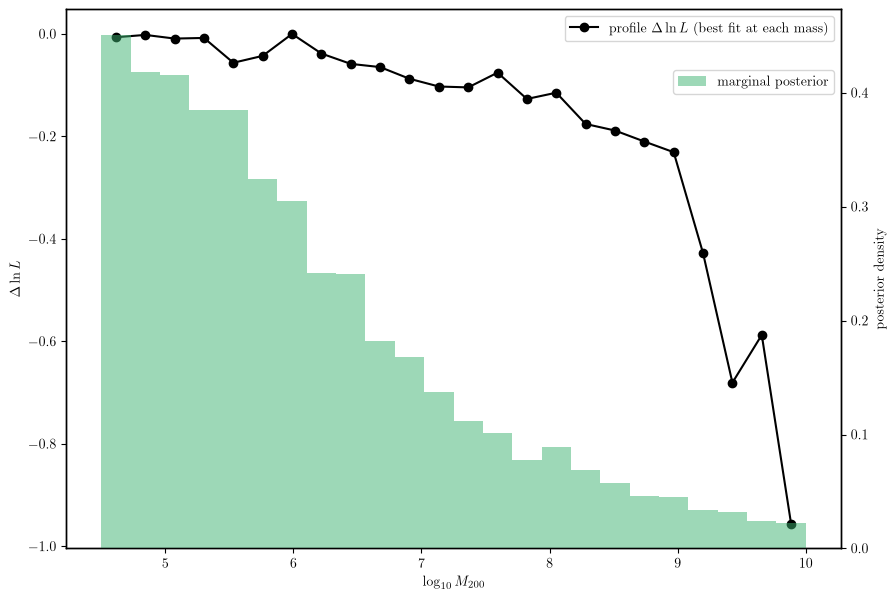

In [52]:
edges = np.linspace(minarr[iM], maxarr[iM], 25)
cen = 0.5*(edges[1:] + edges[:-1])
xs, ll = resu.samples[:, iM], resu.logl
prof = np.array([ll[(xs >= a) & (xs < b)].max() if np.any((xs >= a) & (xs < b)) else np.nan
                 for a, b in zip(edges[:-1], edges[1:])])

fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(cen, prof - np.nanmax(prof), 'o-', color='k', label='profile $\Delta\ln L$ (best fit at each mass)')
ax2 = ax.twinx()
ax2.hist(s1flat[:, iM], bins=edges, density=True, color=col, label='marginal posterior', alpha=0.5)
ax.set_xlabel(r'$\log_{10} M_{200}$'); ax.set_ylabel(r'$\Delta \ln L$')
ax2.set_ylabel('posterior density')
ax.legend()
ax2.legend(bbox_to_anchor=(1, 0.9))
plt.show()



logM200 = 3 : 74 / 100 draws fit
logM200 = 5 : 79 / 100 draws fit
logM200 = 7 : 53 / 100 draws fit
logM200 = 9 : 15 / 100 draws fit


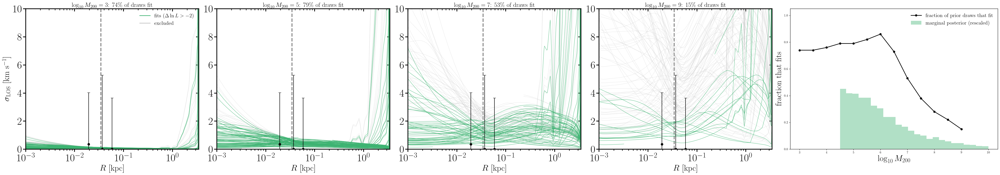

In [53]:
#--- fine-tuning test: fix M200, draw the other dynamical parameters from the prior ------------
base_ml = resu.samples[np.argmax(resu.logl)]
iM = 2*n_betpars + nu_components
lnL_best = resu.logl.max()
dlnL_cut = 2.0                                   # "fits" = within ~95% of the best fit

# parameters drawn from the prior: anisotropy (0-7) and halo shape (c, rc, n, rt, delta)
free_idx = list(range(0, 2*n_betpars)) + list(range(iM+1, iM+6))

ndraw = 100
rng = np.random.default_rng(0)
U = rng.random((ndraw, len(free_idx)))           # SAME draws reused at every mass
lo, hi = minarr[free_idx], maxarr[free_idx]


def make_theta(logM, k):
    th = np.copy(base_ml)
    th[free_idx] = lo + (hi - lo)*U[k]
    th[iM] = logM
    return th


def safe_lnL(th):
    try:
        v = lnprob(th)
    except Exception:
        return -np.inf
    return v if np.isfinite(v) else -np.inf


#--- panels at a few masses: every draw's sigma_LOS, coloured if it fits ---------------------
show_M = [3, 5, 7, 9]
curves, fits = {}, {}
for lm in show_M:
    curves[lm] = np.array([sigma_los_model(make_theta(lm, k), Ra) for k in range(ndraw)])
    fits[lm]   = np.array([safe_lnL(make_theta(lm, k)) for k in range(ndraw)]) > lnL_best - dlnL_cut
    print('logM200 = %d : %d / %d draws fit' % (lm, fits[lm].sum(), ndraw))

#--- fraction that fits vs mass (finer grid, lnL only) ---------------------------------------
M_grid = np.arange(3.0, 9.01, 0.5)
frac = np.array([np.mean([safe_lnL(make_theta(lm, k)) > lnL_best - dlnL_cut for k in range(ndraw)])
                 for lm in M_grid])

#--- plot --------------------------------------------------------------------------------------
fig, axes = plt.subplots(1, len(show_M) + 1, figsize=(9*(len(show_M) + 1), 8),
                         gridspec_kw=dict(width_ratios=[1]*len(show_M) + [1.2]))

for ax, lm in zip(axes[:-1], show_M):
    c, f = curves[lm], fits[lm]
    ax.plot(Ra, c[~f].T, color='0.75', lw=0.6, alpha=0.5, zorder=1)
    ax.plot(Ra, c[f].T,  color=col,    lw=1.0, alpha=0.8, zorder=2)
    ax.errorbar(Rb, sb, yerr=sberr, fmt='o', color='k', ms=7, capsize=4, lw=1.5, zorder=5)
    pretty_ax(ax, 0.0, 10.0)
    ax.set_title(r'$\log_{10} M_{200} = %d$: %d\%% of draws fit' % (lm, 100*f.mean()), fontsize=fsl*0.6)
    ax.set_xlabel(r'$R$ [kpc]', fontsize=fsl*0.8)
axes[0].set_ylabel(r'$\sigma_{\rm LOS}$ [km s$^{-1}$]', fontsize=fsl*0.8)
axes[0].plot([], [], color=col, lw=2, label=r'fits ($\Delta\ln L > -%.0f$)' % dlnL_cut)
axes[0].plot([], [], color='0.75', lw=2, label='excluded')
axes[0].legend(frameon=False, fontsize=fsl*0.5, loc='upper right')

ax = axes[-1]
ax.plot(M_grid, frac, 'o-', color='k', lw=2, label='fraction of prior draws that fit')
ax.hist(s1flat[:, iM], bins=np.linspace(minarr[iM], maxarr[iM], 25), density=True,
        color=col, alpha=0.4, label='marginal posterior (rescaled)',
        weights=np.full(len(s1flat), frac.max()/np.histogram(s1flat[:, iM], bins=24, density=True)[0].max()))
ax.set_xlabel(r'$\log_{10} M_{200}$', fontsize=fsl*0.8)
ax.set_ylabel('fraction that fits', fontsize=fsl*0.8)
ax.set_ylim(0, 1.05)
ax.legend(frameon=False, fontsize=fsl*0.5, loc='upper right')

plt.tight_layout()
plt.show()
